# PATSTAT Patent Metrics — Validation & Visualization

The PatentView pipeline re-run, kernel for kernel, at **application** level on PATSTAT Global 2023 Autumn: 84.9 M
applications for patents of invention from every office, 1900–2023. There is no gold standard, so — as in
`patent_validation` and `dimension_validation` — every figure either checks an invariant the build must satisfy
(asserted) or reproduces a known regularity. Two sections are specific to this index:

- **§15 Filing vs grant clock.** The pipeline is stored twice: `PATSTAT/output/` dates both ends of a citation by
  **filing** year and keeps every application (the PATSTAT / OECD convention); `PATSTAT/output_grant/` dates them
  by **grant** year and keeps granted applications only (PatentView's convention). §15 compares the two on the
  applications that are in both.
- **§16 PATSTAT vs PatentView.** US grants are matched to PatentView by patent number (`tls211.publn_nr` of the
  first grant publication = PatentView `patent_id`), and grant year, citations, CD and inventors are compared.

- **§17–§18 Applications vs DOCDB families.** `PATSTAT/output_family/` re-runs the chain with the DOCDB family as the
  unit (`NB_PS_UNIT=family`): an invention filed at several offices is one node, citations are distinct family-to-family
  pairs (within-family citations dropped) and both ends are dated by the family's earliest priority year. §17 checks the
  family set against the application set it is built from and against EPO's own family citation count; §18 compares
  citations and disruption on the two units.

Sections 1–14 use the filing clock and the application unit unless a panel says otherwise.

## Inputs
```
PATSTAT/output/        patstat_{metadata, reference, citation, citation_trend, disruption, disruption_trend_summary,
PATSTAT/output_grant/          hit_probability, sb, z_score, inventor, inventor_country}.parquet   (same names, two clocks)
PATSTAT/output_family/ the same files, one row per DOCDB family, key docdb_family_id (sections 17-18)
PATSTAT/raw/tls211     US grant publication numbers (section 16)
PatentView/output/     patent_{metadata, citation, disruption, inventor, inventor_country}.parquet  (section 16)
```
Conventions of the source tables (`PATSTAT/Readme.txt`): a citation counts when `age >= 0 AND NOT replenished`
(`ps.EDGE_WHERE`); `C_*` count citation rows, `uniqueC_*` distinct citing applications (the impact count);
`ni/nj/nk = -1` and CD/F/E/G null mean "nothing in the window"; the hit-probability cohort is WIPO sector × clock
year; the CD percentile cohort is filing year × CPC Section in both sets.

In [1]:
import os, sys, gc
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('patstat_validation')
sys.path.insert(0, V.PS_BASE)
import ps_common as ps                      # EDGE_WHERE, raw(); the clock switch is not used here -- both sets are read by path
EDGE = ps.EDGE_WHERE

def files(P):
    return {k: P(f'patstat_{k}.parquet') for k in ('metadata', 'reference', 'citation', 'citation_trend', 'disruption',
            'disruption_trend_summary', 'hit_probability', 'sb', 'z_score', 'inventor', 'inventor_country')}
FL, GR = files(V.patstat), files(V.patstat_grant)        # filing clock, grant clock
FA = files(V.patstat_family)                              # DOCDB families, priority year (sections 17-18)
ZPAIR = V.patstat('z_score_pair.parquet')
PV = {k: V.patent(f'patent_{k}.parquet') for k in ('metadata', 'citation', 'disruption', 'inventor', 'inventor_country')}

BLUE, ORANGE, AQUA, VIOLET, RED = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7', '#c44e52'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#e6e5e1', '#fcfcfb'
SNAP = ps.SNAP_YEAR             # 2023: the last year in the Autumn 2023 edition
YEAR_MIN = 1950                 # trend panels start here; the corpus is thin before
OFFICE_COL = {'US': BLUE, 'JP': ORANGE, 'CN': RED, 'EP': AQUA, 'KR': VIOLET, 'DE': '#8c6d31', 'WO': '#6b7280', 'FR': '#d4a017'}

def style(ax, xlab=None, ylab=None, title=None):
    ax.set_facecolor(SURFACE); ax.grid(axis='y', color=GRID, lw=.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=3)
    for sp in ax.spines.values():
        sp.set_color(GRID)
    if xlab: ax.set_xlabel(xlab, color=MUTED)
    if ylab: ax.set_ylabel(ylab, color=MUTED)
    if title: ax.set_title(title, color=INK, loc='left', pad=8)
    return ax

def q(sql):
    return con.execute(sql).fetchdf()

con = duckdb.connect()
con.execute(f"SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '160GB')}'")
con.execute(f"SET threads={int(os.environ.get('SLURM_CPUS_PER_TASK', '8'))}")
TMPDIR = f'{V.TMP}/patstat_validation_{os.getpid()}'           # never share a spill folder between DuckDB processes
os.makedirs(TMPDIR, exist_ok=True); con.execute(f"SET temp_directory='{TMPDIR}'")
con.execute('SET preserve_insertion_order=false')
assert V.preflight('patstat_validation'), 'an input is missing -- see the list above'
N_F = con.execute(f"SELECT count(*) FROM read_parquet('{FL['metadata']}')").fetchone()[0]
N_G = con.execute(f"SELECT count(*) FROM read_parquet('{GR['metadata']}')").fetchone()[0]
print(f'filing-clock universe {N_F:,} applications | grant-clock universe {N_G:,} ({N_G / N_F * 100:.1f}%)')

[val] patstat_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/patstat_validation_<section>.{jpg,pdf}  @ 600 dpi
  patstat_validation  OK


filing-clock universe 84,914,026 applications | grant-clock universe 44,819,975 (52.8%)


## 1. Coverage — how many applications have each metric defined, on each clock

The share of the clock's universe with the metric defined. Citations, disruption and the beauty coefficient need a
citer, so they cover the cited part of the universe only; atypicality needs ≥ 2 CPC subclasses, inventors a tls207
inventor row. The grant-clock universe is the granted applications, so its shares are of a smaller base.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

clock,filing,grant
metric,,
granted,53.68,100.00
cited (uniqueC_all > 0),48.17,47.26
CD_5 defined,37.71,36.28
CD_all defined,48.17,47.26
hit percentile (WIPO sector),96.25,95.92
beauty coefficient (n_cite >= 5),18.77,19.53
atypicality (>= 2 CPC subclasses),40.36,40.23
inventors,89.05,87.65
inventor country,41.95,45.28


/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_1.jpg + .pdf  (600 dpi)


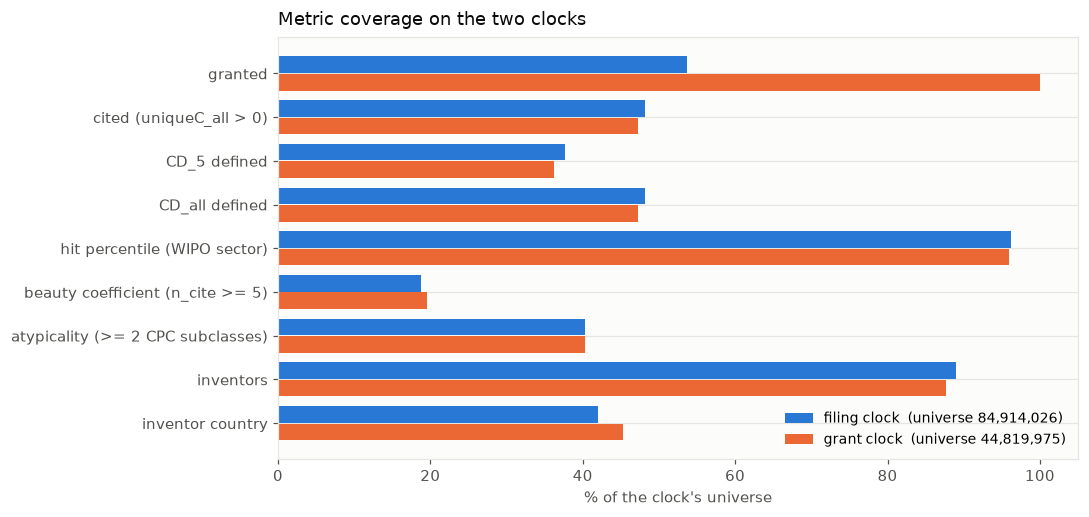

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,clock,edges,counted,counted_pct
0,filing,401559169,385534965,96.01
1,grant,244099237,235453552,96.46


CPU times: user 14.7 s, sys: 1.02 s, total: 15.7 s
Wall time: 1min 6s


In [2]:
%%time
rows = []
for clock, P, N in (('filing', FL, N_F), ('grant', GR, N_G)):
    for label, f, cond in (('granted', 'metadata', 'granted'), ('cited (uniqueC_all > 0)', 'citation', 'uniqueC_all > 0'),
                           ('CD_5 defined', 'disruption', 'CD_5 IS NOT NULL'), ('CD_all defined', 'disruption', 'CD_all IS NOT NULL'),
                           ('hit percentile (WIPO sector)', 'hit_probability', 'pctl_call IS NOT NULL'),
                           ('beauty coefficient (n_cite >= 5)', 'sb', 'n_cite >= 5'), ('atypicality (>= 2 CPC subclasses)', 'z_score', 'Z_median IS NOT NULL'),
                           ('inventors', 'inventor', 'n_inventors > 0'), ('inventor country', 'inventor_country', 'countries IS NOT NULL')):
        k = con.execute(f"SELECT count(*) FILTER (WHERE {cond}) FROM read_parquet('{P[f]}')").fetchone()[0]
        rows.append(dict(clock=clock, metric=label, applications=k, pct=k / N * 100))
cov = pd.DataFrame(rows)
display(cov.pivot(index='metric', columns='clock', values='pct').round(2).loc[cov.metric.unique()])
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
labels = list(cov.metric.unique()); y = np.arange(len(labels))
for off, (clock, c) in zip((-.2, .2), (('filing', BLUE), ('grant', ORANGE))):
    v = cov[cov.clock == clock].set_index('metric').loc[labels, 'pct']
    ax.barh(y + off, v, height=.38, color=c, label=f'{clock} clock  (universe {N_F if clock == "filing" else N_G:,})')
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
style(ax, '% of the clock\'s universe', None, 'Metric coverage on the two clocks'); ax.legend(frameon=False, fontsize=9, loc='lower right')
V.save('1')
edges = q(f"""SELECT 'filing' AS clock, count(*) AS edges, count(*) FILTER (WHERE {EDGE}) AS counted FROM read_parquet('{FL['reference']}')
              UNION ALL SELECT 'grant', count(*), count(*) FILTER (WHERE {EDGE}) FROM read_parquet('{GR['reference']}')""")
edges['counted_pct'] = (edges.counted / edges.edges * 100).round(2); display(edges)

## 2. The corpus in time — filing years, offices, grants and grant lags

PATSTAT is worldwide, so its composition moves with the offices: the Chinese office dominates filings after 2010.
The office shares stop two years before the snapshot, because offices publish (18 months after filing) at different
speeds. The grant share falls at the right edge because recent applications have not been decided yet, and the lag from
filing to grant differs by office — the reason the grant clock is not a uniform shift of the filing clock.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_2.jpg + .pdf  (600 dpi)


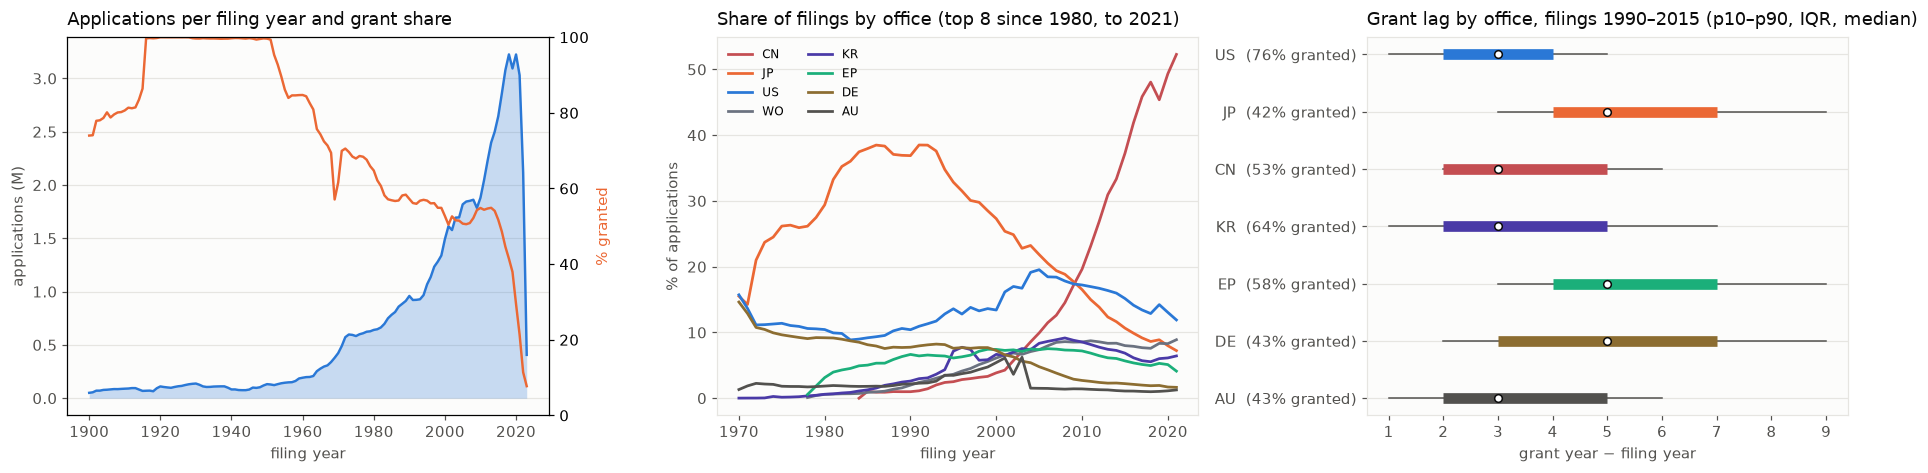

,appln_auth,n,pct_granted,p10,median_lag,p90
0,US,5039188,76.32,1.0,3.0,5.0
1,JP,3896729,42.45,3.0,5.0,9.0
2,CN,3121642,52.77,2.0,3.0,6.0
3,KR,1827572,63.59,1.0,3.0,7.0
4,EP,1662392,58.35,3.0,5.0,9.0
5,DE,858566,42.59,2.0,5.0,9.0
6,AU,440233,42.52,1.0,3.0,6.0


CPU times: user 11 s, sys: 498 ms, total: 11.5 s
Wall time: 18.2 s


In [3]:
%%time
yr = q(f"""SELECT filing_year AS year, count(*) AS n, avg(granted::INT) AS granted, avg(ref_count) AS refs
          FROM read_parquet('{FL['metadata']}') WHERE filing_year BETWEEN 1900 AND {SNAP} GROUP BY 1 ORDER BY 1""")
TOP = q(f"SELECT appln_auth, count(*) AS n FROM read_parquet('{FL['metadata']}') WHERE filing_year >= 1980 GROUP BY 1 ORDER BY n DESC LIMIT 8").appln_auth.tolist()
off = q(f"""SELECT filing_year AS year, appln_auth, count(*) AS n FROM read_parquet('{FL['metadata']}')
           WHERE filing_year BETWEEN 1970 AND {SNAP - 2} AND appln_auth IN ({', '.join(repr(a) for a in TOP)}) GROUP BY 1, 2""")
# stops at SNAP - 2: offices publish 18 months after filing at different speeds, so the last two years over-weight the fast ones
off = off.merge(yr[['year', 'n']].rename(columns={'n': 'tot'}), on='year')
lag = q(f"""SELECT appln_auth, count(*) AS n, quantile_cont(grant_year - filing_year, [0.1, 0.25, 0.5, 0.75, 0.9]) AS qs
          FROM read_parquet('{FL['metadata']}') WHERE grant_year IS NOT NULL AND filing_year BETWEEN 1990 AND 2015
            AND appln_auth IN ({', '.join(repr(a) for a in TOP)}) GROUP BY 1 ORDER BY n DESC""")
gsh = q(f"""SELECT appln_auth, avg(granted::INT) * 100 AS pct_granted FROM read_parquet('{FL['metadata']}')
          WHERE filing_year BETWEEN 1990 AND 2015 AND appln_auth IN ({', '.join(repr(a) for a in TOP)}) GROUP BY 1""")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
ax[0].fill_between(yr.year, yr.n / 1e6, color=BLUE, alpha=.25, lw=0); ax[0].plot(yr.year, yr.n / 1e6, lw=1.6, color=BLUE, label='applications')
a2 = ax[0].twinx(); a2.plot(yr.year, yr.granted * 100, lw=1.6, color=ORANGE, label='% granted'); a2.set_ylabel('% granted', color=ORANGE); a2.set_ylim(0, 100)
style(ax[0], 'filing year', 'applications (M)', 'Applications per filing year and grant share')
for a in TOP:
    s = off[off.appln_auth == a].sort_values('year'); ax[1].plot(s.year, s.n / s.tot * 100, lw=1.8, color=OFFICE_COL.get(a, MUTED), label=a)
style(ax[1], 'filing year', '% of applications', f'Share of filings by office (top 8 since 1980, to {SNAP - 2})'); ax[1].legend(frameon=False, fontsize=8, ncol=2)
lag = lag.merge(gsh, on='appln_auth')
for i, r in enumerate(lag.itertuples()):
    q10, q25, q50, q75, q90 = r.qs
    ax[2].plot([q10, q90], [i, i], color=MUTED, lw=1); ax[2].plot([q25, q75], [i, i], color=OFFICE_COL.get(r.appln_auth, MUTED), lw=7, solid_capstyle='butt')
    ax[2].plot(q50, i, 'o', color='white', mec=INK, ms=5)
ax[2].set_yticks(range(len(lag))); ax[2].set_yticklabels([f'{a}  ({g:.0f}% granted)' for a, g in zip(lag.appln_auth, lag.pct_granted)])
ax[2].invert_yaxis(); style(ax[2], 'grant year − filing year', None, 'Grant lag by office, filings 1990–2015 (p10–p90, IQR, median)')
V.save('2')
display(lag.assign(p10=[x[0] for x in lag.qs], median_lag=[x[2] for x in lag.qs], p90=[x[4] for x in lag.qs]).drop(columns='qs').round(2))

## 3. Forward citations — invariants, distribution and provenance

Asserted for every cited application: the windows are nested (`C_3 ≤ C_5 ≤ C_10 ≤ C_all`, and the same for
`uniqueC`), a distinct citing application is at most one row (`uniqueC ≤ C`), and the three provenance buckets add
up to the total. The third panel splits the counted edges by who added the citation, by citing filing year:
PATSTAT records the origin of every citation, so "applicant" here is a real category, not PatentView's proxy.

,cited,C_not_nested,uniqueC_not_nested,uniqueC_gt_C,buckets_not_summing
0,40901611,0,0,0,0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_3.jpg + .pdf  (600 dpi)


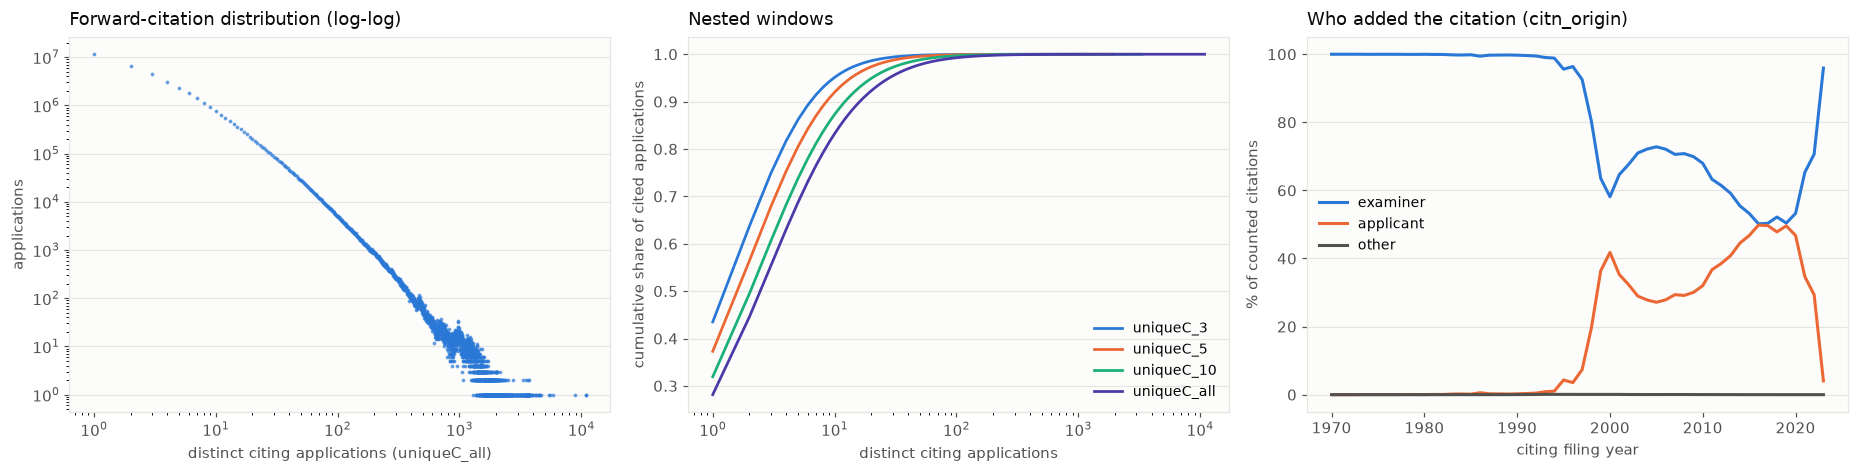

,cited,mean_uniqueC_all,mean_C_all,rows_per_citing_app,max_uniqueC_all,never_cited_pct
0,40901611,8.2,9.426,1.149,10879,51.83


CPU times: user 21.2 s, sys: 761 ms, total: 22 s
Wall time: 12 s


In [4]:
%%time
chk = q(f"""SELECT count(*) AS cited,
   count(*) FILTER (WHERE C_3 > C_5 OR C_5 > C_10 OR C_10 > C_all) AS C_not_nested,
   count(*) FILTER (WHERE uniqueC_3 > uniqueC_5 OR uniqueC_5 > uniqueC_10 OR uniqueC_10 > uniqueC_all) AS uniqueC_not_nested,
   count(*) FILTER (WHERE uniqueC_all > C_all OR uniqueC_5 > C_5) AS uniqueC_gt_C,
   count(*) FILTER (WHERE C_all <> C_examiner_all + C_applicant_all + C_other_all) AS buckets_not_summing
   FROM read_parquet('{FL['citation']}')""")
display(chk); assert int(chk.iloc[0, 1:].sum()) == 0, 'a citation-count invariant is violated'
d = q(f"SELECT uniqueC_all AS v, count(*) AS n FROM read_parquet('{FL['citation']}') WHERE uniqueC_all > 0 GROUP BY 1 ORDER BY 1")
prov = q(f"""SELECT citing_year AS year, bucket, count(*) AS n FROM read_parquet('{FL['reference']}')
            WHERE {EDGE} AND citing_year BETWEEN 1970 AND {SNAP} GROUP BY 1, 2""").pivot(index='year', columns='bucket', values='n').fillna(0)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
ax[0].loglog(d.v, d.n, '.', ms=3, color=BLUE, alpha=.6); style(ax[0], 'distinct citing applications (uniqueC_all)', 'applications', 'Forward-citation distribution (log-log)')
for w, c in (('uniqueC_3', BLUE), ('uniqueC_5', ORANGE), ('uniqueC_10', AQUA), ('uniqueC_all', VIOLET)):
    dd = q(f"SELECT {w} AS v, count(*) AS n FROM read_parquet('{FL['citation']}') WHERE {w} > 0 GROUP BY 1 ORDER BY 1")
    ax[1].semilogx(dd.v, dd.n.cumsum() / dd.n.sum(), lw=1.8, color=c, label=w)
style(ax[1], 'distinct citing applications', 'cumulative share of cited applications', 'Nested windows'); ax[1].legend(frameon=False, fontsize=9)
sh = prov.div(prov.sum(axis=1), axis=0) * 100
for b, c in (('examiner', BLUE), ('applicant', ORANGE), ('other', MUTED)):
    if b in sh: ax[2].plot(sh.index, sh[b], lw=2, color=c, label=b)
style(ax[2], 'citing filing year', '% of counted citations', 'Who added the citation (citn_origin)'); ax[2].legend(frameon=False, fontsize=9)
V.save('3')
st = q(f"""SELECT count(*) AS cited, round(avg(uniqueC_all), 3) AS mean_uniqueC_all, round(avg(C_all), 3) AS mean_C_all,
          round(sum(C_all)::DOUBLE / sum(uniqueC_all), 3) AS rows_per_citing_app, max(uniqueC_all) AS max_uniqueC_all FROM read_parquet('{FL['citation']}')""")
st['never_cited_pct'] = round((1 - st.cited[0] / N_F) * 100, 2); display(st)

## 4. Mean citations by filing year — and the truncation it exposes

Every application in the universe counts (uncited ones as zero). Each window is solid only while it has fully
elapsed before the 2023 snapshot (`year ≤ SNAP − w`); `uniqueC_all` has no closing year and is the series most
damaged by truncation. The right panel splits the 5-year count by provenance.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_4.jpg + .pdf  (600 dpi)


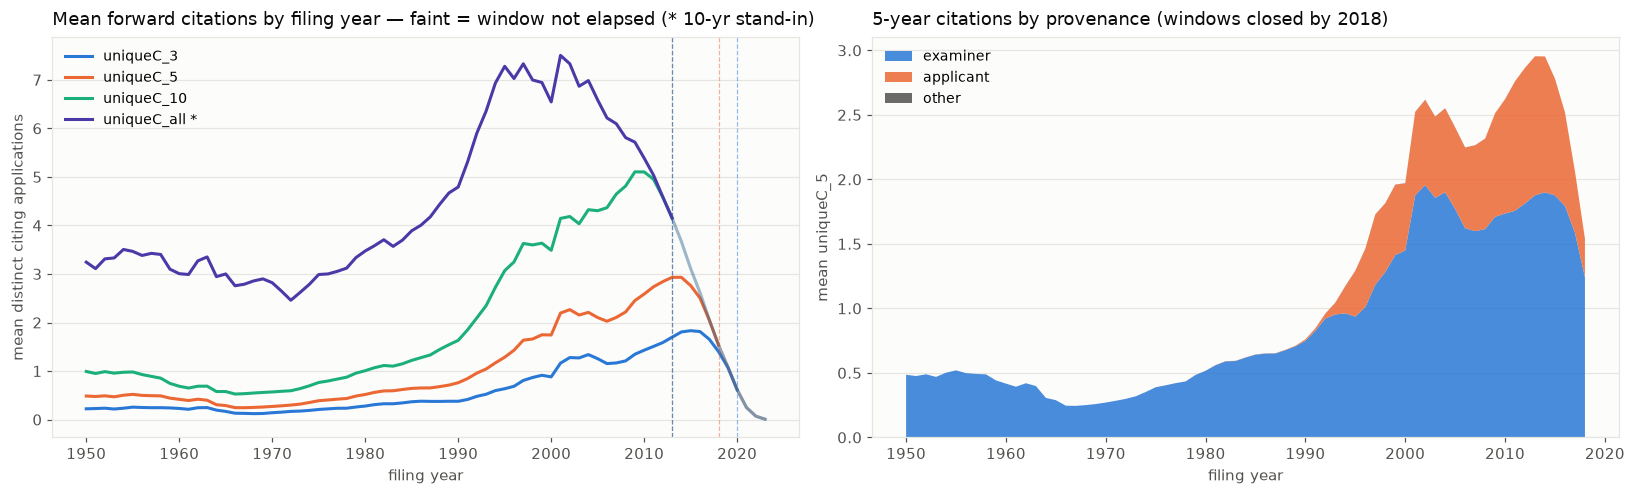

,year,n,u3,u5,u10,uall,ex5,ap5,ot5
10,1960,192220,0.229,0.417,0.687,3.006,0.417,0.000,0.000
30,1980,640660,0.279,0.517,1.007,3.474,0.516,0.001,0.000
40,1990,959481,0.377,0.759,1.633,4.792,0.748,0.012,0.001
50,2000,1492407,0.880,1.743,3.487,6.545,1.449,0.521,0.001
55,2005,1818620,1.254,2.102,4.303,6.583,1.770,0.632,0.001
60,2010,1880647,1.430,2.587,5.102,5.386,1.735,0.886,0.000
65,2015,2645123,1.832,2.760,3.110,3.110,1.875,0.905,0.000
68,2018,3225473,1.399,1.533,1.533,1.533,1.241,0.299,0.000


CPU times: user 16.9 s, sys: 832 ms, total: 17.8 s
Wall time: 5.96 s


In [5]:
%%time
g = q(f"""SELECT m.filing_year AS year, count(*) AS n,
          avg(coalesce(c.uniqueC_3, 0)) AS u3, avg(coalesce(c.uniqueC_5, 0)) AS u5, avg(coalesce(c.uniqueC_10, 0)) AS u10, avg(coalesce(c.uniqueC_all, 0)) AS uall,
          avg(coalesce(c.uniqueC_examiner_5, 0)) AS ex5, avg(coalesce(c.uniqueC_applicant_5, 0)) AS ap5, avg(coalesce(c.uniqueC_other_5, 0)) AS ot5
        FROM read_parquet('{FL['metadata']}') m LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
        WHERE m.filing_year BETWEEN {YEAR_MIN} AND {SNAP} GROUP BY 1 ORDER BY 1""")
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), layout='constrained')
for col, w, c, lab in (('u3', 3, BLUE, 'uniqueC_3'), ('u5', 5, ORANGE, 'uniqueC_5'), ('u10', 10, AQUA, 'uniqueC_10'), ('uall', 10, VIOLET, 'uniqueC_all *')):
    closed = SNAP - w; s = g[g.year <= closed]; f = g[g.year >= closed]
    ax[0].plot(s.year, s[col], lw=2, color=c, label=lab); ax[0].plot(f.year, f[col], lw=2, color=c, alpha=.28); ax[0].axvline(closed, color=c, lw=.8, ls='--', alpha=.5)
style(ax[0], 'filing year', 'mean distinct citing applications', 'Mean forward citations by filing year — faint = window not elapsed (* 10-yr stand-in)'); ax[0].legend(frameon=False, fontsize=9)
s = g[g.year <= SNAP - 5]
ax[1].stackplot(s.year, s.ex5, s.ap5, s.ot5, colors=[BLUE, ORANGE, MUTED], labels=['examiner', 'applicant', 'other'], alpha=.85)
style(ax[1], 'filing year', 'mean uniqueC_5', '5-year citations by provenance (windows closed by 2018)'); ax[1].legend(frameon=False, fontsize=9, loc='upper left')
V.save('4')
display(g[g.year.isin([1960, 1980, 1990, 2000, 2005, 2010, 2015, 2018])].round(3))

## 5. Citation age profile — when an application gets cited, on both clocks

From `patstat_citation_trend.parquet` (full history, not four windows). On the filing clock the citing
application's filing year can precede the cited application's grant by years; on the grant clock both ends are
grant years, so the profile is compressed toward zero and the mass that was early citation of a pending
application moves to ages ≤ 0 (negative ages are excluded by `EDGE_WHERE`).

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_5.jpg + .pdf  (600 dpi)


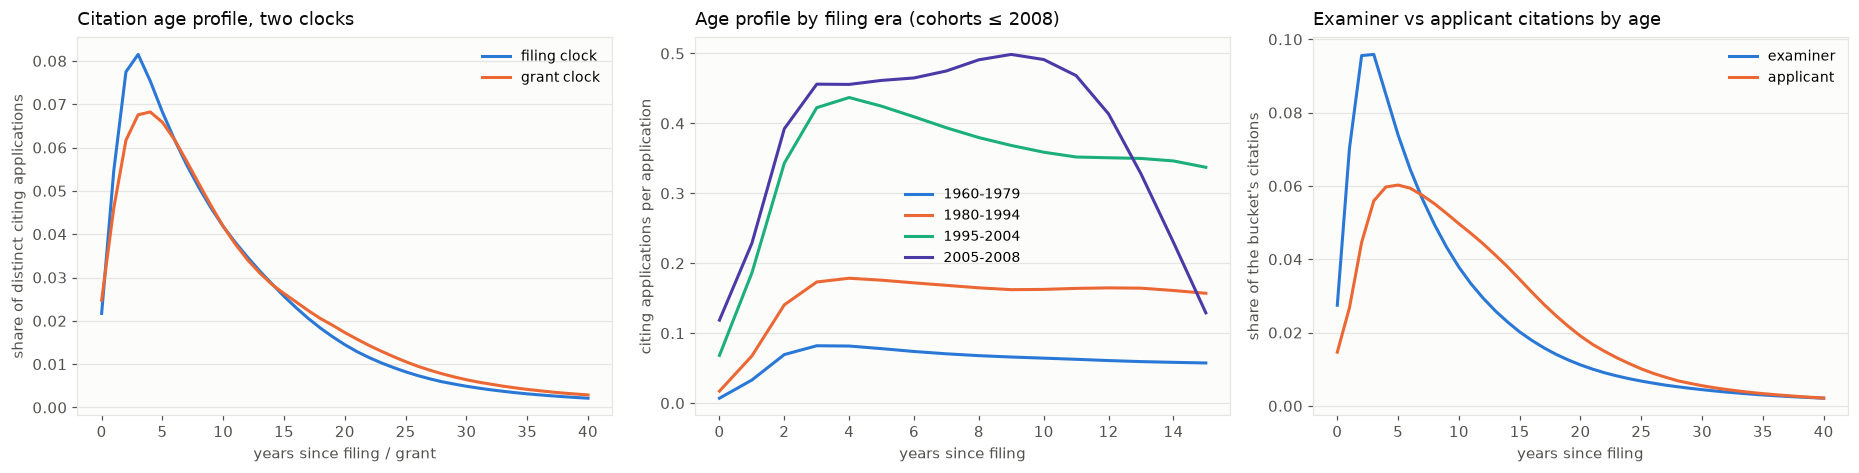

peak age: filing clock 3 y, grant clock 4 y; median age: filing 8 y, grant 8 y
CPU times: user 14.5 s, sys: 541 ms, total: 15.1 s
Wall time: 5.61 s


In [6]:
%%time
af = q(f"SELECT yrs_since_filing AS age, sum(C) AS C, sum(uniqueC) AS u, sum(C_examiner) AS ex, sum(C_applicant) AS ap FROM read_parquet('{FL['citation_trend']}') WHERE yrs_since_filing <= 40 GROUP BY 1 ORDER BY 1")
ag = q(f"SELECT yrs_since_grant AS age, sum(C) AS C, sum(uniqueC) AS u FROM read_parquet('{GR['citation_trend']}') WHERE yrs_since_grant <= 40 GROUP BY 1 ORDER BY 1")
era = q(f"""SELECT CASE WHEN filing_year < 1980 THEN '1960-1979' WHEN filing_year < 1995 THEN '1980-1994' WHEN filing_year < 2005 THEN '1995-2004' ELSE '2005-2008' END AS era,
           yrs_since_filing AS age, sum(uniqueC) AS u FROM read_parquet('{FL['citation_trend']}')
           WHERE yrs_since_filing <= 15 AND filing_year BETWEEN 1960 AND 2008 GROUP BY 1, 2""")
nera = q(f"""SELECT CASE WHEN filing_year < 1980 THEN '1960-1979' WHEN filing_year < 1995 THEN '1980-1994' WHEN filing_year < 2005 THEN '1995-2004' ELSE '2005-2008' END AS era,
            count(*) AS apps FROM read_parquet('{FL['metadata']}') WHERE filing_year BETWEEN 1960 AND 2008 GROUP BY 1""")
era = era.merge(nera, on='era'); era['per_app'] = era.u / era.apps
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
ax[0].plot(af.age, af.u / af.u.sum(), lw=2, color=BLUE, label='filing clock'); ax[0].plot(ag.age, ag.u / ag.u.sum(), lw=2, color=ORANGE, label='grant clock')
style(ax[0], 'years since filing / grant', 'share of distinct citing applications', 'Citation age profile, two clocks'); ax[0].legend(frameon=False, fontsize=9)
for (e, gg), c in zip(era.sort_values('age').groupby('era'), (BLUE, ORANGE, AQUA, VIOLET)):
    ax[1].plot(gg.age, gg.per_app, lw=2, color=c, label=e)
style(ax[1], 'years since filing', 'citing applications per application', 'Age profile by filing era (cohorts ≤ 2008)'); ax[1].legend(frameon=False, fontsize=9)
ax[2].plot(af.age, af.ex / af.ex.sum(), lw=2, color=BLUE, label='examiner'); ax[2].plot(af.age, af.ap / af.ap.sum(), lw=2, color=ORANGE, label='applicant')
style(ax[2], 'years since filing', 'share of the bucket\'s citations', 'Examiner vs applicant citations by age'); ax[2].legend(frameon=False, fontsize=9)
V.save('5')
print(f'peak age: filing clock {int(af.age[af.u.idxmax()])} y, grant clock {int(ag.age[ag.u.idxmax()])} y; '
      f'median age: filing {int(af.age[(af.u.cumsum() / af.u.sum()) >= .5].iloc[0])} y, grant {int(ag.age[(ag.u.cumsum() / ag.u.sum()) >= .5].iloc[0])} y')

## 6. Disruption — CD distribution, its trend on both clocks, and the ni / nj / nk composition

CD is bounded in [−1, +1]; the spikes at 0 and ±1 are few-citer arithmetic, which is why the distribution is also
drawn for applications with ≥ 10 citers. The middle panel draws mean CD<sub>5</sub> by year on each clock (windows
closed by 2018). The composition panel is the diagnostic: a drift in CD only means something once you know which
term moved. The 1900–1970s level is inflated by left-censoring — references older than the index are missing,
so n<sub>k</sub> is undercounted (the same artefact as PatentView 1976–79).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_6.jpg + .pdf  (600 dpi)


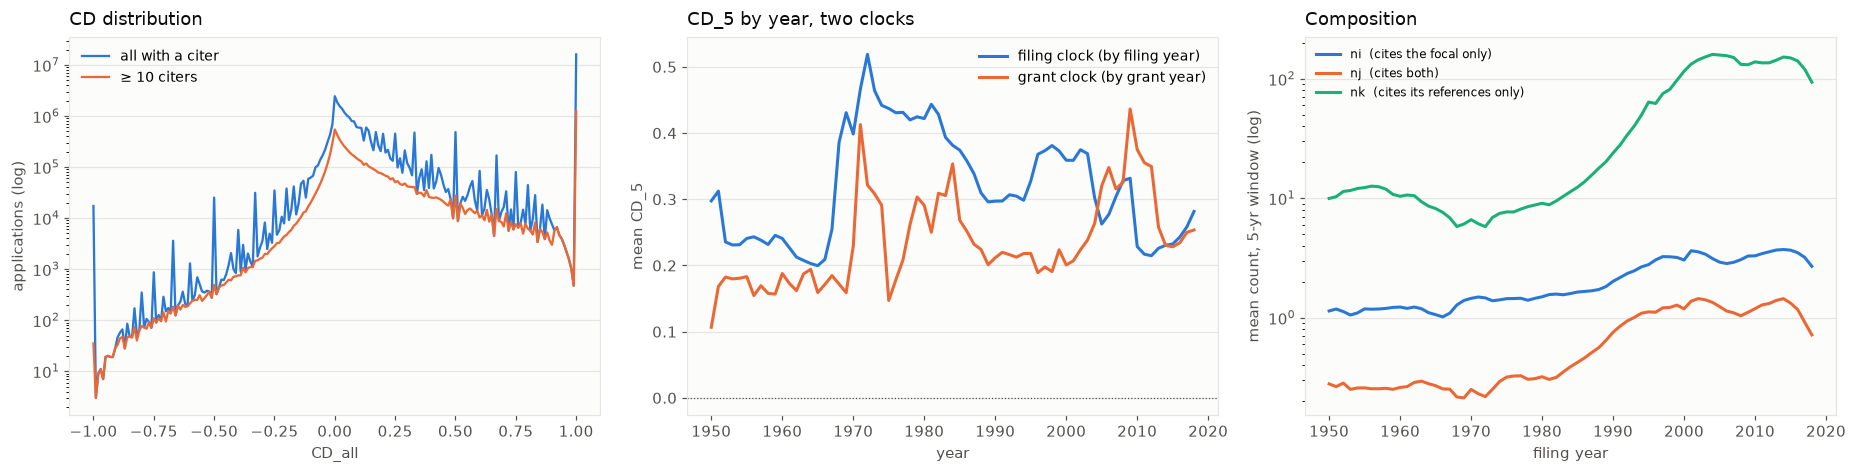

,mean_CD_5,median_CD_5,pct_plus1,pct_zero,pct_positive
0,0.302,0.0753,24.05,15.86,73.18


CPU times: user 24.7 s, sys: 965 ms, total: 25.7 s
Wall time: 19 s


In [7]:
%%time
assert q(f"SELECT count(*) AS bad FROM read_parquet('{FL['disruption']}') WHERE CD_5 < -1 OR CD_5 > 1 OR CD_all < -1 OR CD_all > 1").bad[0] == 0, 'CD outside [-1, 1]'
h = q(f"""SELECT round(CD_all, 2) AS cd, count(*) AS all_apps, count(*) FILTER (WHERE ni_all + nj_all >= 10) AS cited10
         FROM read_parquet('{FL['disruption']}') WHERE CD_all IS NOT NULL GROUP BY 1 ORDER BY 1""")
comp = q(f"""SELECT m.filing_year AS year, count(*) AS n, avg(d.ni_5) AS ni, avg(d.nj_5) AS nj, avg(d.nk_5) AS nk, avg(d.CD_5) AS cd5
            FROM read_parquet('{FL['disruption']}') d JOIN read_parquet('{FL['metadata']}') m USING (appln_id)
            WHERE d.CD_5 IS NOT NULL AND m.filing_year BETWEEN {YEAR_MIN} AND {SNAP - 5} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""")
compg = q(f"""SELECT m.grant_year AS year, count(*) AS n, avg(d.CD_5) AS cd5
             FROM read_parquet('{GR['disruption']}') d JOIN read_parquet('{GR['metadata']}') m USING (appln_id)
             WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YEAR_MIN} AND {SNAP - 5} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
ax[0].semilogy(h.cd, h.all_apps, lw=1.5, color=BLUE, label='all with a citer'); ax[0].semilogy(h.cd, h.cited10, lw=1.5, color=ORANGE, label='≥ 10 citers')
style(ax[0], 'CD_all', 'applications (log)', 'CD distribution'); ax[0].legend(frameon=False, fontsize=9)
ax[1].plot(comp.year, comp.cd5, lw=2, color=BLUE, label='filing clock (by filing year)'); ax[1].plot(compg.year, compg.cd5, lw=2, color=ORANGE, label='grant clock (by grant year)')
ax[1].axhline(0, color=MUTED, lw=.8, ls=':'); style(ax[1], 'year', 'mean CD_5', 'CD_5 by year, two clocks'); ax[1].legend(frameon=False, fontsize=9)
for col, c, lab in (('ni', BLUE, 'ni  (cites the focal only)'), ('nj', ORANGE, 'nj  (cites both)'), ('nk', AQUA, 'nk  (cites its references only)')):
    ax[2].plot(comp.year, comp[col], lw=2, color=c, label=lab)
ax[2].set_yscale('log'); style(ax[2], 'filing year', 'mean count, 5-yr window (log)', 'Composition'); ax[2].legend(frameon=False, fontsize=8)
V.save('6')
display(q(f"""SELECT round(avg(CD_5),4) AS mean_CD_5, round(median(CD_5),4) AS median_CD_5, round(100.0*avg((CD_5 = 1)::INT),2) AS pct_plus1,
             round(100.0*avg((CD_5 = 0)::INT),2) AS pct_zero, round(100.0*avg((CD_5 > 0)::INT),2) AS pct_positive FROM read_parquet('{FL['disruption']}') WHERE CD_5 IS NOT NULL"""))

## 7. F / E / G — the citing profile (5-year window)

`F + E + G = 1` for every application with a citer in the window, asserted. Then the three shares by filing year,
and the share of citers that also cite the focal application's own references (n<sub>j</sub> / (n<sub>i</sub> + n<sub>j</sub>)).

,defined,not_summing_to_1
0,28150712,0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_7.jpg + .pdf  (600 dpi)


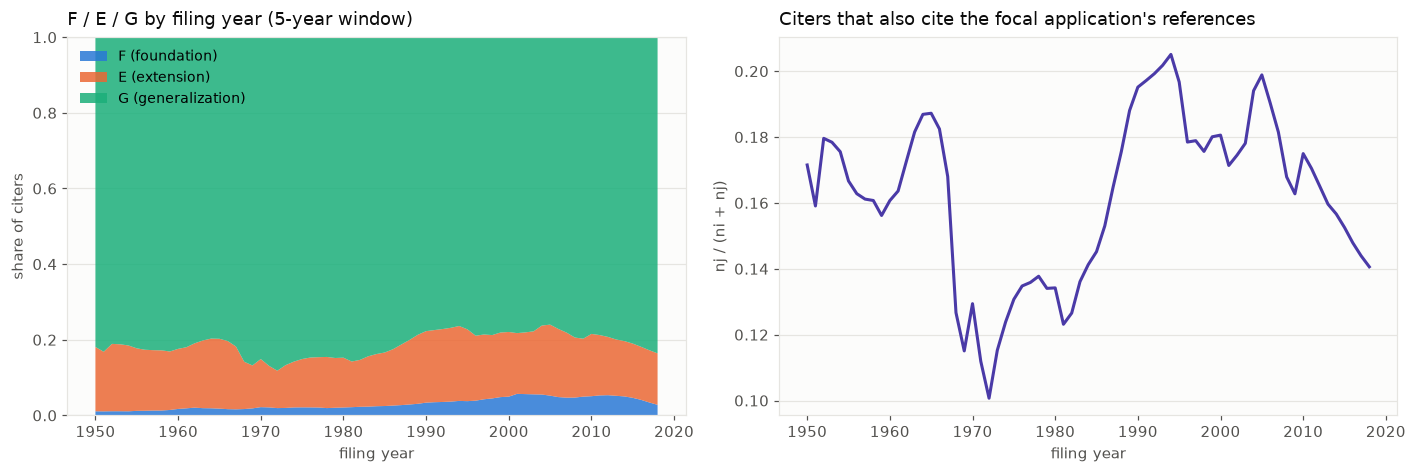

,year,n,F,E,G,njfrac
20,1970,49934,0.0218,0.1272,0.8509,0.1294
30,1980,141603,0.0209,0.1317,0.8473,0.1342
40,1990,204529,0.0338,0.1891,0.7772,0.1951
50,2000,522296,0.0496,0.1710,0.7794,0.1806
60,2010,935297,0.0508,0.1647,0.7845,0.1750
68,2018,1451447,0.0279,0.1362,0.8359,0.1406


CPU times: user 13.2 s, sys: 613 ms, total: 13.9 s
Wall time: 4.88 s


In [8]:
%%time
chk = q(f"SELECT count(*) AS defined, count(*) FILTER (WHERE abs(F_5 + E_5 + G_5 - 1) > 1e-4) AS not_summing_to_1 FROM read_parquet('{FL['disruption']}') WHERE F_5 IS NOT NULL")
display(chk); assert int(chk.not_summing_to_1[0]) == 0, 'F + E + G must be 1 for every defined application'
feg = q(f"""SELECT m.filing_year AS year, count(*) AS n, avg(d.F_5) AS F, avg(d.E_5) AS E, avg(d.G_5) AS G,
           avg(d.nj_5 * 1.0 / nullif(d.ni_5 + d.nj_5, 0)) AS njfrac FROM read_parquet('{FL['disruption']}') d JOIN read_parquet('{FL['metadata']}') m USING (appln_id)
           WHERE d.F_5 IS NOT NULL AND m.filing_year BETWEEN {YEAR_MIN} AND {SNAP - 5} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), layout='constrained')
ax[0].stackplot(feg.year, feg.F, feg.E, feg.G, colors=[BLUE, ORANGE, AQUA], labels=['F (foundation)', 'E (extension)', 'G (generalization)'], alpha=.85)
style(ax[0], 'filing year', 'share of citers', 'F / E / G by filing year (5-year window)'); ax[0].legend(frameon=False, fontsize=9, loc='upper left'); ax[0].set_ylim(0, 1)
ax[1].plot(feg.year, feg.njfrac, lw=2, color=VIOLET); style(ax[1], 'filing year', 'nj / (ni + nj)', 'Citers that also cite the focal application\'s references')
V.save('7')
display(feg[feg.year.isin([1970, 1980, 1990, 2000, 2010, 2018])].round(4))

## 8. Hit percentile — and the zero-inflation a percentile cannot hide

`pctl_*` ranks an application inside its WIPO sector × filing-year cohort with ties at the lowest rank, so a large
block sits at 0 wherever most applications are uncited. The distribution is not uniform and should not be; the top
1 % share per sector is near 1 % only where ties do not straddle the threshold.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_8.jpg + .pdf  (600 dpi)


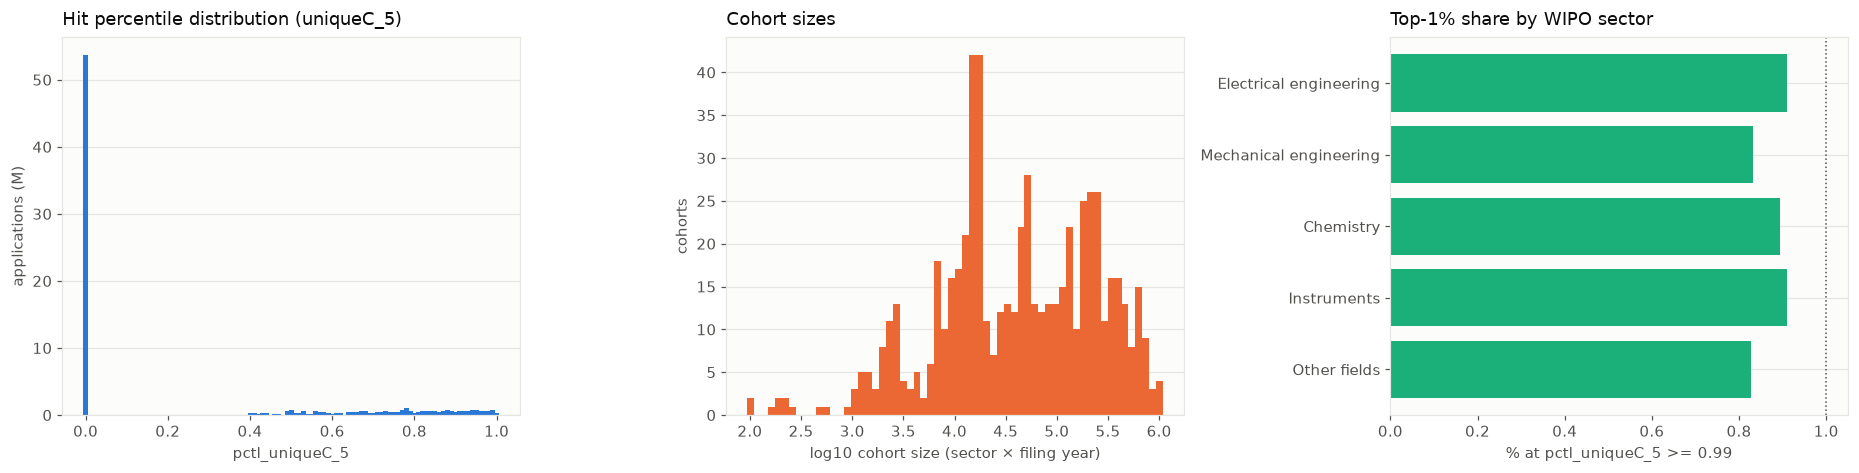

,wipo_sector,apps,pct_top1,pct_at_min
0,Electrical engineering,23650775,0.911,58.2
1,Mechanical engineering,20076410,0.831,70.5
2,Chemistry,19943664,0.893,69.5
3,Instruments,11549810,0.910,62.6
4,Other fields,6510652,0.827,71.5


CPU times: user 10 s, sys: 195 ms, total: 10.2 s
Wall time: 4.16 s


In [9]:
%%time
hp = q(f"SELECT round(pctl_uniqueC_5, 2) AS p, count(*) AS n FROM read_parquet('{FL['hit_probability']}') GROUP BY 1 ORDER BY 1")
cn = q(f"SELECT wipo_sector, filing_year, count(*) AS cohort_n FROM read_parquet('{FL['hit_probability']}') GROUP BY 1, 2")
top = q(f"""SELECT wipo_sector, count(*) AS apps, round(100.0*count(*) FILTER (WHERE pctl_uniqueC_5 >= 0.99)/count(*), 3) AS pct_top1,
           round(100.0*count(*) FILTER (WHERE pctl_uniqueC_5 = min_p)/count(*), 1) AS pct_at_min
           FROM (SELECT *, min(pctl_uniqueC_5) OVER (PARTITION BY wipo_sector, filing_year) AS min_p FROM read_parquet('{FL['hit_probability']}'))
           GROUP BY 1 ORDER BY apps DESC""")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
ax[0].bar(hp.p, hp.n / 1e6, width=.012, color=BLUE); style(ax[0], 'pctl_uniqueC_5', 'applications (M)', 'Hit percentile distribution (uniqueC_5)')
ax[1].hist(np.log10(cn.cohort_n), bins=60, color=ORANGE); style(ax[1], 'log10 cohort size (sector × filing year)', 'cohorts', 'Cohort sizes')
ax[2].barh(top.wipo_sector[::-1], top.pct_top1[::-1], color=AQUA); ax[2].axvline(1, color=MUTED, ls=':', lw=1)
style(ax[2], '% at pctl_uniqueC_5 >= 0.99', None, 'Top-1% share by WIPO sector')
V.save('8')
display(top)

## 9. By WIPO sector and CPC section — do the strata behave?

If the field strata are useful, metric means should differ across them by more than noise and in ways that make
sense (e.g. chemistry and instruments cited more, mechanical engineering less). Filing clock, filings 1990–2013 so
the 10-year window is closed for everyone.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,stratum,apps,mean_uniqueC_10,mean_CD_5,mean_refs,median_SB_B_n20,mean_Z_median
0,Electrical engineering,11252358,5.711,0.3037,5.11,5.997,403.42
1,Instruments,5177345,5.451,0.2695,5.63,9.615,213.10
2,Chemistry,8865800,2.916,0.3085,3.42,9.690,637.25
3,Other fields,2613413,2.748,0.2877,3.90,10.733,283.46
4,Mechanical engineering,7756016,2.616,0.2923,3.63,10.240,256.18


,stratum,apps,mean_uniqueC_10,mean_CD_5,mean_refs,median_SB_B_n20,mean_Z_median
0,A,4880811,5.137,0.1616,6.19,10.872,685.23
1,B,4537064,3.343,0.1867,4.92,9.750,187.89
2,C,3421247,3.028,0.2179,3.99,9.500,504.93
3,D,318622,2.105,0.2234,3.65,11.000,211.60
4,E,795530,2.987,0.1906,4.98,10.333,360.93
5,F,2035970,3.244,0.2119,4.67,9.542,371.84
6,G,4985346,6.979,0.1899,7.00,6.514,251.85
7,H,4964762,5.748,0.2224,5.68,5.600,500.86
8,Y,595351,3.389,0.5509,1.55,8.000,419.58


/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_9.jpg + .pdf  (600 dpi)


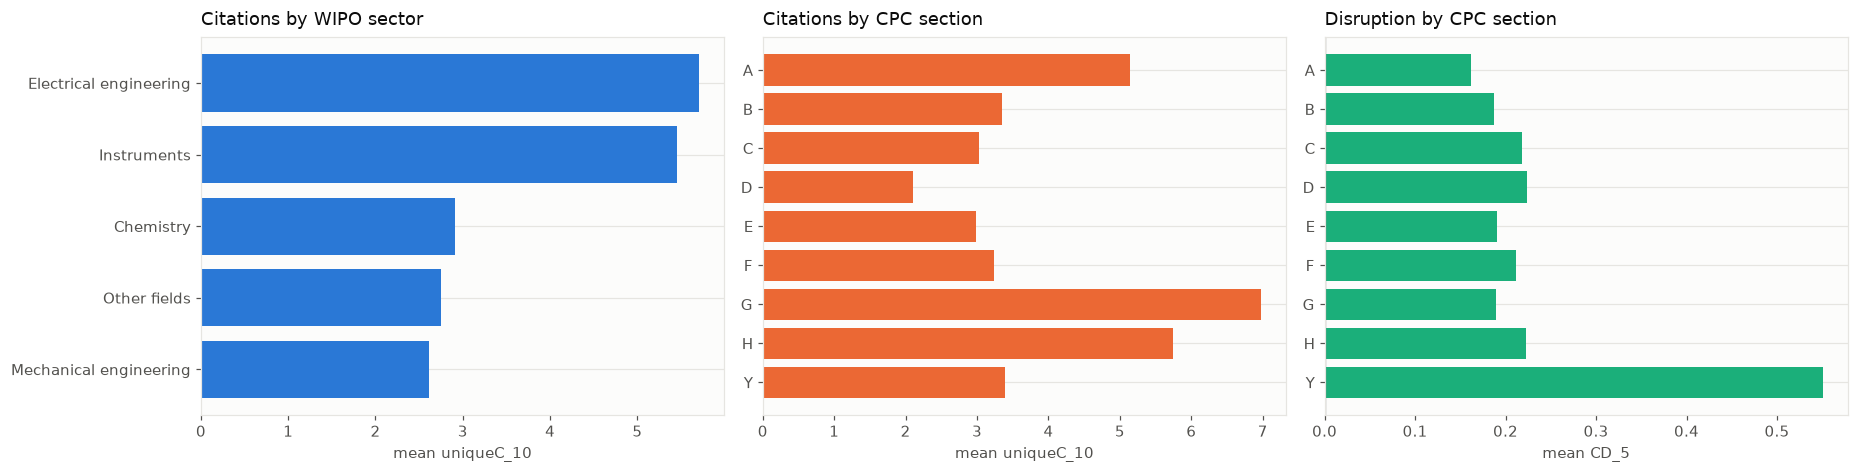

CPU times: user 58.6 s, sys: 3.79 s, total: 1min 2s
Wall time: 19.3 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/patstat_validation_9.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patstat_validation_9.pdf']

In [10]:
%%time
base = f"""FROM read_parquet('{FL['metadata']}') m LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
           LEFT JOIN read_parquet('{FL['disruption']}') d USING (appln_id) LEFT JOIN read_parquet('{FL['sb']}') s USING (appln_id)
           LEFT JOIN read_parquet('{FL['z_score']}') z USING (appln_id) WHERE m.filing_year BETWEEN 1990 AND 2013"""
aggs = """count(*) AS apps, round(avg(coalesce(c.uniqueC_10, 0)), 3) AS mean_uniqueC_10, round(avg(d.CD_5), 4) AS mean_CD_5,
          round(avg(m.ref_count), 2) AS mean_refs, round(median(s.SB_B) FILTER (WHERE s.n_cite >= 20), 3) AS median_SB_B_n20, round(avg(z.Z_median), 2) AS mean_Z_median"""
bys = q(f"SELECT m.wipo_sector AS stratum, {aggs} {base} AND m.wipo_sector IS NOT NULL GROUP BY 1 ORDER BY mean_uniqueC_10 DESC")
byc = q(f"SELECT left(m.cpc_code, 1) AS stratum, {aggs} {base} AND m.cpc_code IS NOT NULL GROUP BY 1 HAVING count(*) >= 10000 ORDER BY 1")
display(bys); display(byc)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
o = bys.sort_values('mean_uniqueC_10'); ax[0].barh(o.stratum, o.mean_uniqueC_10, color=BLUE); style(ax[0], 'mean uniqueC_10', None, 'Citations by WIPO sector')
o = byc.sort_values('stratum', ascending=False); ax[1].barh(o.stratum, o.mean_uniqueC_10, color=ORANGE); style(ax[1], 'mean uniqueC_10', None, 'Citations by CPC section')
ax[2].barh(o.stratum, o.mean_CD_5, color=AQUA); ax[2].axvline(0, color=MUTED, lw=.8); style(ax[2], 'mean CD_5', None, 'Disruption by CPC section')
V.save('9')

## 10. Cross-metric correlations

Spearman on a 500k random sample of the filing-clock universe (uncited applications count as zero citations).
Expected signs: CD relates **negatively** to citations, `ref_count` positively to n<sub>j</sub>, the hit percentile
tracks `uniqueC_5` almost perfectly, and `uniqueC_all` should track PATSTAT's own family-level citing count
`nb_citing_docdb_fam` — an independent count EPO computes on DOCDB families.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patstat_validation_10.jpg + .pdf  (600 dpi)


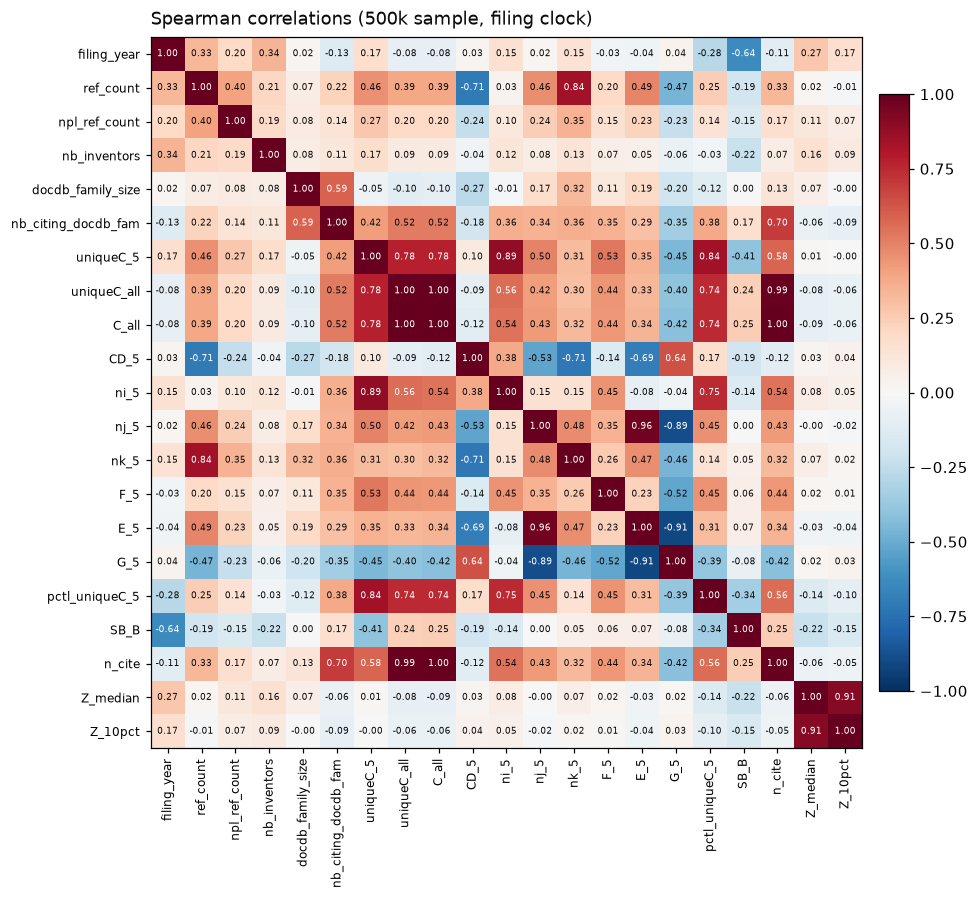

  uniqueC_all        vs nb_citing_docdb_fam  +0.519
  uniqueC_5          vs pctl_uniqueC_5       +0.837
  uniqueC_all        vs CD_5                 -0.095
  ref_count          vs nj_5                 +0.465
  n_cite             vs SB_B                 +0.248
  nb_inventors       vs uniqueC_all          +0.091
  docdb_family_size  vs uniqueC_all          -0.104
CPU times: user 36.7 s, sys: 3.62 s, total: 40.3 s
Wall time: 23.1 s


In [11]:
%%time
smp = q(f"""WITH m AS (SELECT * FROM read_parquet('{FL['metadata']}') USING SAMPLE reservoir(500000 ROWS) REPEATABLE (7))
  SELECT m.filing_year, m.ref_count, m.npl_ref_count, m.nb_inventors, m.docdb_family_size, m.nb_citing_docdb_fam,
         coalesce(c.uniqueC_5, 0) AS uniqueC_5, coalesce(c.uniqueC_all, 0) AS uniqueC_all, coalesce(c.C_all, 0) AS C_all,
         d.CD_5, nullif(d.ni_5, -1) AS ni_5, nullif(d.nj_5, -1) AS nj_5, nullif(d.nk_5, -1) AS nk_5, d.F_5, d.E_5, d.G_5,
         h.pctl_uniqueC_5, s.SB_B, s.n_cite, z.Z_median, z.Z_10pct
  FROM m LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id) LEFT JOIN read_parquet('{FL['disruption']}') d USING (appln_id)
  LEFT JOIN read_parquet('{FL['hit_probability']}') h USING (appln_id) LEFT JOIN read_parquet('{FL['sb']}') s USING (appln_id)
  LEFT JOIN read_parquet('{FL['z_score']}') z USING (appln_id)""")
cr = smp.corr(method='spearman', numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8.4), layout='constrained')
im = ax.imshow(cr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cr))); ax.set_xticklabels(cr.columns, rotation=90, fontsize=8); ax.set_yticks(range(len(cr))); ax.set_yticklabels(cr.columns, fontsize=8)
for i in range(len(cr)):
    for j in range(len(cr)):
        v = cr.iloc[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='white' if abs(v) > .55 else INK)
ax.set_title('Spearman correlations (500k sample, filing clock)', color=INK, loc='left', pad=8); fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
V.save('10')
for a, b in (('uniqueC_all', 'nb_citing_docdb_fam'), ('uniqueC_5', 'pctl_uniqueC_5'), ('uniqueC_all', 'CD_5'), ('ref_count', 'nj_5'),
             ('n_cite', 'SB_B'), ('nb_inventors', 'uniqueC_all'), ('docdb_family_size', 'uniqueC_all')):
    print(f'  {a:<18} vs {b:<20} {cr.loc[a, b]:+.3f}')

## 11. Sleeping beauties

`B` is meaningless on a handful of citations, so everything is restricted to `n_cite ≥ 50` (citation rows); the right
panel checks that the awakening time of high-`B` applications sits well away from zero.

1,240,429 applications with >= 50 citations | SB_B median 11.83  p99 366.1  max 9434 | B == 0: 4.2%


/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_11.jpg + .pdf  (600 dpi)


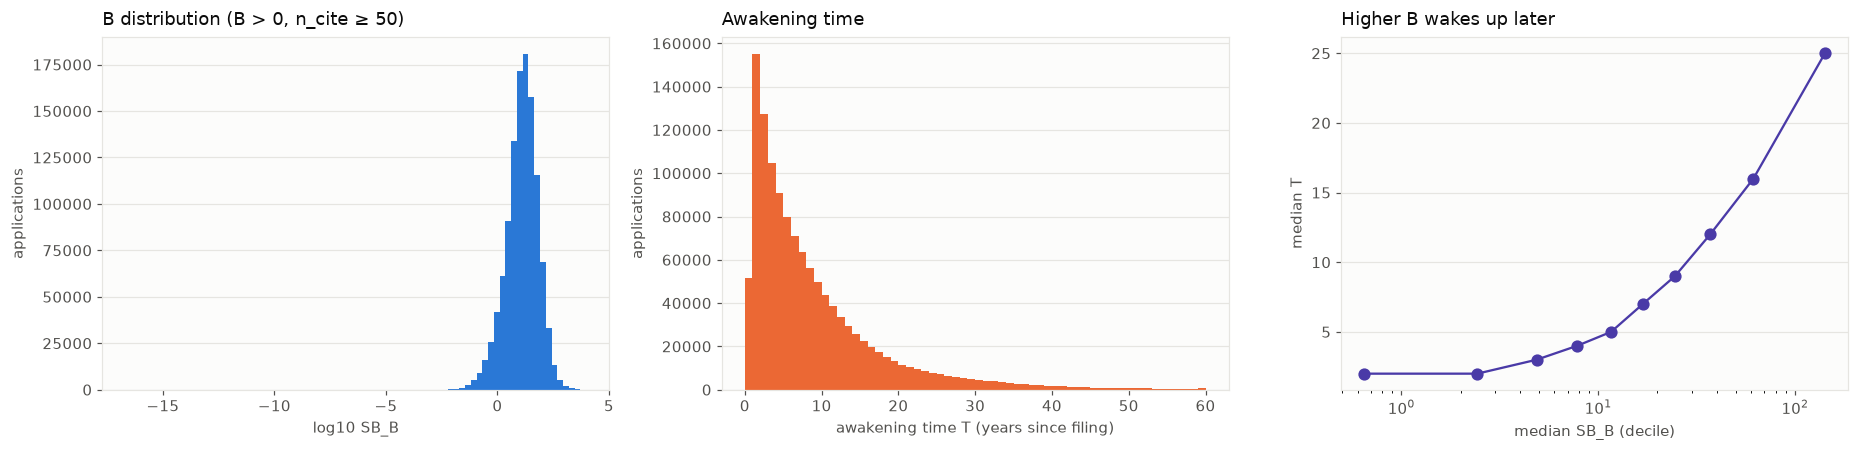

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,appln_id,appln_auth,appln_nr,filing_year,wipo_sector,cpc_code,SB_B,SB_T,n_cite
0,46707104,US,1900034380,1900,None,F16D3/18,9434.400391,110,1055
1,10303921,DE,273689D,1913,Instruments,A61B17/2833,9108.599609,98,982
2,46790935,US,1901075443,1901,None,A61M25/04,8939.599609,111,696
3,19277770,FR,459743D,1912,Mechanical engineering,F16C1/04,8900.500000,99,943
4,46693304,US,1900017136,1900,None,F16L3/04,8861.500000,109,1127
5,46939765,US,1904218435,1904,None,A61C5/85,8386.700195,108,717
6,47284646,US,1909488300,1909,None,F16B15/0015,8089.600098,100,1125
7,47796273,US,2604315,1915,None,B25B13/44,7162.200195,98,536
8,50422008,US,37945229,1929,Mechanical engineering,F16H1/16,6775.700195,82,984
9,49530021,US,31316228,1928,Mechanical engineering,F16C1/08,6677.600098,84,694


CPU times: user 14.7 s, sys: 812 ms, total: 15.5 s
Wall time: 5.92 s


In [12]:
%%time
sb = q(f"SELECT SB_B, SB_T, n_cite FROM read_parquet('{FL['sb']}') WHERE n_cite >= 50")
print(f'{len(sb):,} applications with >= 50 citations | SB_B median {sb.SB_B.median():.2f}  p99 {sb.SB_B.quantile(.99):.1f}  max {sb.SB_B.max():.0f} | B == 0: {(sb.SB_B == 0).mean() * 100:.1f}%')
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2), layout='constrained')
pos = sb[sb.SB_B > 0]
ax[0].hist(np.log10(pos.SB_B), bins=80, color=BLUE); style(ax[0], 'log10 SB_B', 'applications', 'B distribution (B > 0, n_cite ≥ 50)')
ax[1].hist(sb.SB_T, bins=range(0, 61), color=ORANGE); style(ax[1], 'awakening time T (years since filing)', 'applications', 'Awakening time')
qq = pd.qcut(pos.SB_B, 10, labels=False, duplicates='drop'); gg = pos.groupby(qq).agg(B=('SB_B', 'median'), T=('SB_T', 'median'))
ax[2].plot(gg['B'], gg['T'], 'o-', color=VIOLET, ms=7); ax[2].set_xscale('log'); style(ax[2], 'median SB_B (decile)', 'median T', 'Higher B wakes up later')
V.save('11')
display(q(f"""SELECT s.appln_id, m.appln_auth, m.appln_nr, m.filing_year, m.wipo_sector, m.cpc_code, round(s.SB_B, 1) AS SB_B, s.SB_T, s.n_cite
             FROM read_parquet('{FL['sb']}') s JOIN read_parquet('{FL['metadata']}') m USING (appln_id) WHERE s.n_cite >= 100 ORDER BY s.SB_B DESC LIMIT 12"""))

## 12. Atypicality — Z-score CDF and the 2×2 hit probability (Kim et al. 2016)

Pairs of an application's own CPC subclasses, scored against the cumulative hypergeometric null up to its filing
year. The 2×2 splits each axis at the median of the application's filing-year cohort and re-ranks the hit (top 5 %
of `uniqueC_5`) within WIPO sector × filing year among scored applications filed ≤ 2018, so the overall hit rate is
5 % by construction; the published pattern is that high conventionality with high novelty is hit most often.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_12.jpg + .pdf  (600 dpi)


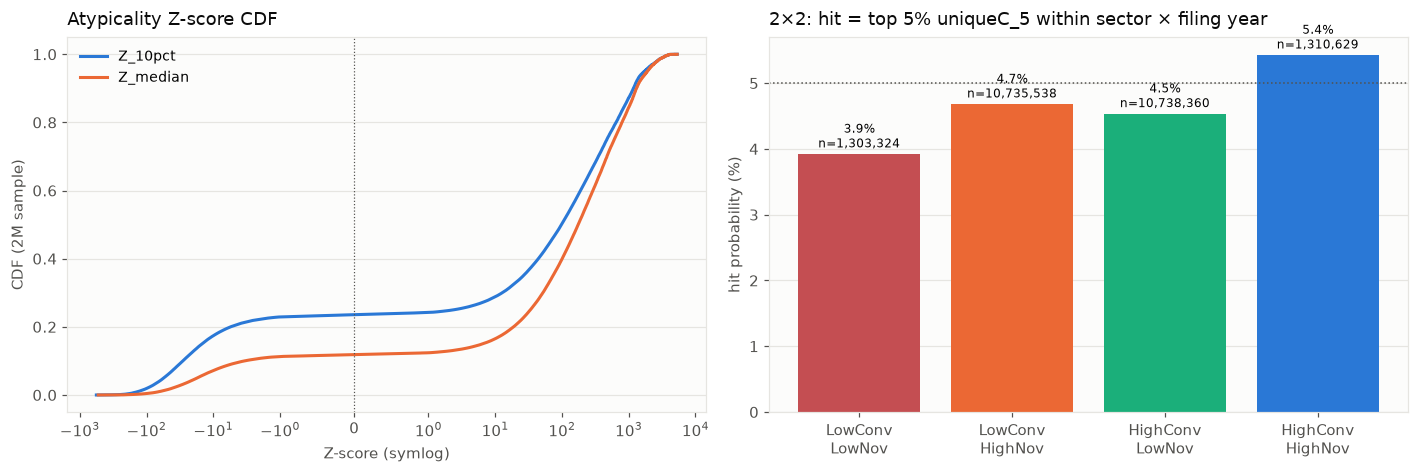

pair table: 2,629,983 (subclass pair, year) rows
          Z_median      Z_10pct      n_pairs
count  2000000.000  2000000.000  2000000.000
mean       458.800      377.037        3.251
std        674.988      654.389        4.788
min       -529.745     -564.655        1.000
25%         33.679        2.388        1.000
50%        175.203       98.403        1.000
75%        608.248      471.272        3.000
max       5336.671     5336.671      465.000
CPU times: user 1min 9s, sys: 5 s, total: 1min 14s
Wall time: 34.6 s


In [13]:
%%time
dz = q(f"SELECT Z_median, Z_10pct, n_pairs FROM read_parquet('{FL['z_score']}') USING SAMPLE reservoir(2000000 ROWS) REPEATABLE (7)")
d = q(f"""WITH s AS (SELECT m.filing_year AS year, m.wipo_sector, z.Z_median, z.Z_10pct, coalesce(c.uniqueC_5, 0) AS u5
             FROM read_parquet('{FL['z_score']}') z JOIN read_parquet('{FL['metadata']}') m USING (appln_id) LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
             WHERE z.Z_median IS NOT NULL AND z.Z_10pct IS NOT NULL AND m.wipo_sector IS NOT NULL AND m.filing_year BETWEEN 1980 AND {SNAP - 5}),
       r AS (SELECT year, Z_median, Z_10pct, percent_rank() OVER (PARTITION BY wipo_sector, year ORDER BY u5) AS cpct FROM s),
       md AS (SELECT year, median(Z_median) AS mc, median(Z_10pct) AS mn FROM r GROUP BY year)
     SELECT (r.Z_median >= md.mc) AS hi_conv, (r.Z_10pct <= md.mn) AS hi_nov, count(*) AS n, avg((r.cpct >= 0.95)::INT) * 100 AS p_hit
     FROM r JOIN md USING (year) GROUP BY 1, 2""")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), layout='constrained')
for col, c in (('Z_10pct', BLUE), ('Z_median', ORANGE)):
    v = np.sort(dz[col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy())
    ax[0].plot(v, np.arange(1, len(v) + 1) / len(v), lw=2, color=c, label=col)
ax[0].set_xscale('symlog', linthresh=1); ax[0].axvline(0, color=MUTED, lw=.8, ls=':'); style(ax[0], 'Z-score (symlog)', 'CDF (2M sample)', 'Atypicality Z-score CDF'); ax[0].legend(frameon=False, fontsize=9)
order = [(False, False), (False, True), (True, False), (True, True)]
lab = ['LowConv\nLowNov', 'LowConv\nHighNov', 'HighConv\nLowNov', 'HighConv\nHighNov']
cell = {(bool(r.hi_conv), bool(r.hi_nov)): r for r in d.itertuples()}
vals = [cell[k].p_hit for k in order]
ax[1].bar(lab, vals, color=[RED, ORANGE, AQUA, BLUE]); ax[1].axhline(5, color=MUTED, ls=':', lw=1)
for i, k in enumerate(order):
    ax[1].text(i, cell[k].p_hit + .1, f'{cell[k].p_hit:.1f}%\nn={int(cell[k].n):,}', ha='center', fontsize=8)
style(ax[1], None, 'hit probability (%)', '2×2: hit = top 5% uniqueC_5 within sector × filing year')
V.save('12')
n_pairs = con.execute(f"SELECT count(*) FROM read_parquet('{ZPAIR}')").fetchone()[0]
print(f'pair table: {n_pairs:,} (subclass pair, year) rows')
print(dz.describe().round(3).to_string())

## 13. Inventors — team size, small teams disrupt, and where inventors sit

`patstat_inventor` counts inventor slots per application (a named person once, an unnamed placeholder once per slot).
The middle panel tests the Wu et al. (2019) pattern — smaller teams disrupt more — which `patent_validation` §17 finds
on US grants. Team size and CD both vary strongly by office and year, so the CD<sub>5</sub> percentile is drawn three
ways: ranked over the pooled worldwide sample (the §17 method), ranked within office × filing year, and for USPTO
filings only (within year), the subset comparable to PatentsView. On this worldwide, filing-clock network the
decline does **not** reproduce: the pooled percentile rises with team size, the within-cohort one rises and then
flattens, and USPTO filings rise to four inventors before falling — unlike PatentView's monotone decline on US
grants (§17 there), whose network is US-only and whose clock is the grant year. The right panel is the international share of
multi-inventor applications with a located inventor, per office, since PATSTAT locates inventors well for some offices only.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_13.jpg + .pdf  (600 dpi)


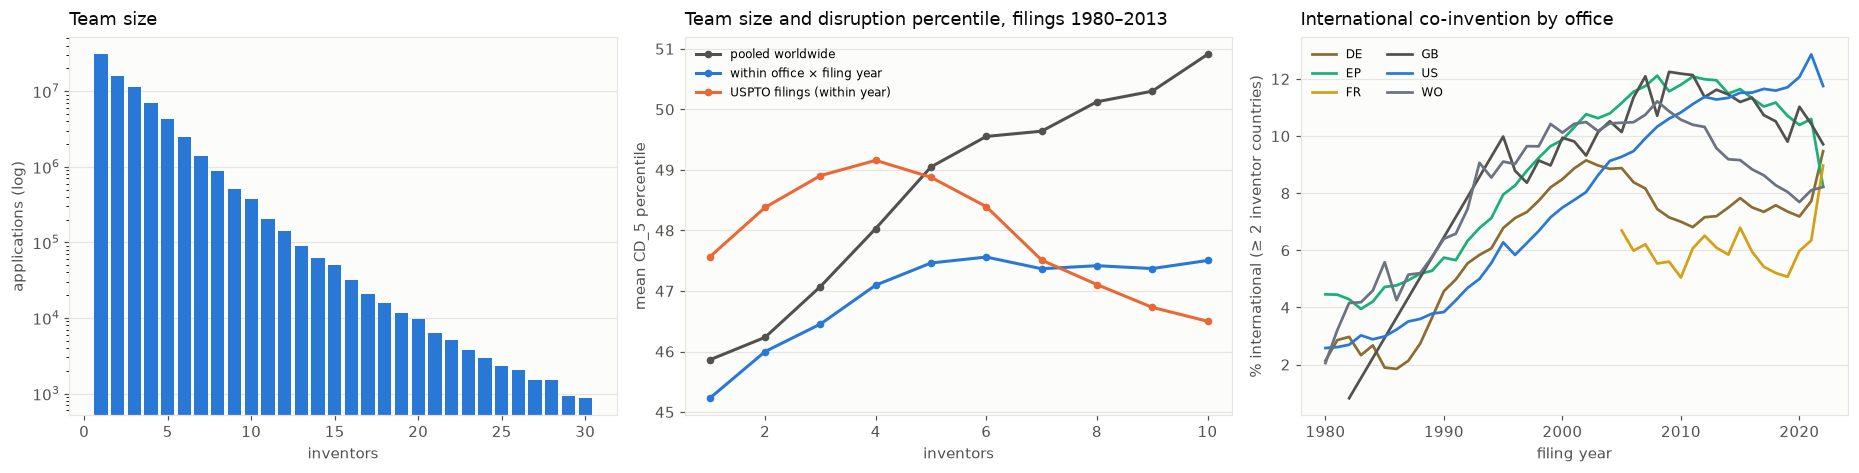

,n_inventors,pooled,within_office_year,us_only,cit,cit_us,n,n_us
0,1,45.862,45.228,47.563,7.572,12.676,5240664,2259656
1,2,46.234,45.999,48.380,9.152,15.228,3435147,1512219
2,3,47.073,46.453,48.904,9.870,16.823,2381692,1000895
3,4,48.031,47.096,49.157,10.524,18.085,1443142,588065
4,5,49.049,47.462,48.877,11.036,19.508,798367,306792
5,6,49.552,47.560,48.393,11.532,20.816,438591,162085
6,7,49.639,47.367,47.510,11.996,21.901,235174,84367
7,8,50.125,47.417,47.106,12.497,23.433,134282,45982
8,9,50.299,47.370,46.729,12.873,24.033,74623,25046
9,10,50.907,47.503,46.500,13.463,25.968,47679,15361


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

inventor country coverage by office, filings 2000-2020:


,appln_auth,apps,pct_located
0,CN,12769882,7.1
1,US,7346009,100.0
2,JP,5985530,0.0
3,WO,3669367,94.6
4,KR,3149634,76.7
5,EP,2927226,99.9
6,DE,1451924,100.0
7,TW,902193,100.0
8,CA,812267,99.8
9,AU,806639,0.4


CPU times: user 53.2 s, sys: 3.37 s, total: 56.6 s
Wall time: 19 s


In [14]:
%%time
ts = q(f"SELECT n_inventors, count(*) AS n FROM read_parquet('{FL['inventor']}') GROUP BY 1 ORDER BY 1")
wu = q(f"""WITH b AS (SELECT d.CD_5, coalesce(c.uniqueC_10, 0) AS u10, i.n_inventors, m.appln_auth, m.filing_year FROM read_parquet('{FL['disruption']}') d
             JOIN read_parquet('{FL['inventor']}') i USING (appln_id) JOIN read_parquet('{FL['metadata']}') m USING (appln_id)
             LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
             WHERE d.CD_5 IS NOT NULL AND i.n_inventors BETWEEN 1 AND 10 AND m.ref_count >= 1 AND m.filing_year BETWEEN 1980 AND 2013),
       r AS (SELECT *, percent_rank() OVER (ORDER BY CD_5) AS dp_pool,
                    percent_rank() OVER (PARTITION BY appln_auth, filing_year ORDER BY CD_5) AS dp_coh FROM b)
     SELECT n_inventors, avg(dp_pool) * 100 AS pooled, avg(dp_coh) * 100 AS within_office_year,
            avg(dp_coh) FILTER (WHERE appln_auth = 'US') * 100 AS us_only, avg(u10) AS cit,
            avg(u10) FILTER (WHERE appln_auth = 'US') AS cit_us, count(*) AS n, count(*) FILTER (WHERE appln_auth = 'US') AS n_us
     FROM r GROUP BY 1 ORDER BY 1""")
intl = q(f"""SELECT m.appln_auth, m.filing_year AS year, avg(ic.is_international::INT) * 100 AS intl, count(*) AS n
            FROM read_parquet('{FL['inventor_country']}') ic JOIN read_parquet('{FL['metadata']}') m USING (appln_id)
            WHERE ic.countries IS NOT NULL AND ic.n_inventors >= 2 AND m.filing_year BETWEEN 1980 AND {SNAP - 1}
              AND m.appln_auth IN ('US', 'EP', 'WO', 'DE', 'FR', 'GB') GROUP BY 1, 2 HAVING count(*) >= 500 ORDER BY 2""")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
t = ts[ts.n_inventors <= 30]; ax[0].bar(t.n_inventors, t.n, color=BLUE); ax[0].set_yscale('log'); style(ax[0], 'inventors', 'applications (log)', 'Team size')
for col, c, lab in (('pooled', MUTED, 'pooled worldwide'), ('within_office_year', BLUE, 'within office × filing year'), ('us_only', ORANGE, 'USPTO filings (within year)')):
    ax[1].plot(wu.n_inventors, wu[col], 'o-', color=c, ms=4, lw=2, label=lab)
style(ax[1], 'inventors', 'mean CD_5 percentile', 'Team size and disruption percentile, filings 1980–2013'); ax[1].legend(frameon=False, fontsize=8)
for a, gg in intl.groupby('appln_auth'):
    ax[2].plot(gg.year, gg.intl, lw=1.8, color=OFFICE_COL.get(a, MUTED), label=a)
style(ax[2], 'filing year', '% international (≥ 2 inventor countries)', 'International co-invention by office'); ax[2].legend(frameon=False, fontsize=8, ncol=2)
V.save('13')
display(wu.round(3))
loc = q(f"""SELECT m.appln_auth, count(*) AS apps, round(100.0 * count(ic.countries) / count(*), 1) AS pct_located
           FROM read_parquet('{FL['inventor_country']}') ic JOIN read_parquet('{FL['metadata']}') m USING (appln_id)
           WHERE m.filing_year BETWEEN 2000 AND 2020 GROUP BY 1 ORDER BY apps DESC LIMIT 12""")
print('inventor country coverage by office, filings 2000-2020:'); display(loc)

## 14. Disruption over age and cohort — the per-application trend

From `patstat_disruption_trend_summary` (mean cumulative CD by filing year × years since filing; the producing
notebook asserts that the cumulative trend reproduces every per-window value of `patstat_disruption`). Left: CD as the
window widens, by filing decade. Right: CD at fixed ages by filing year — the Park, Leahey & Funk (2023) decline
reads off this panel, with the left-censoring caveat of §6 for the early cohorts.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_14.jpg + .pdf  (600 dpi)


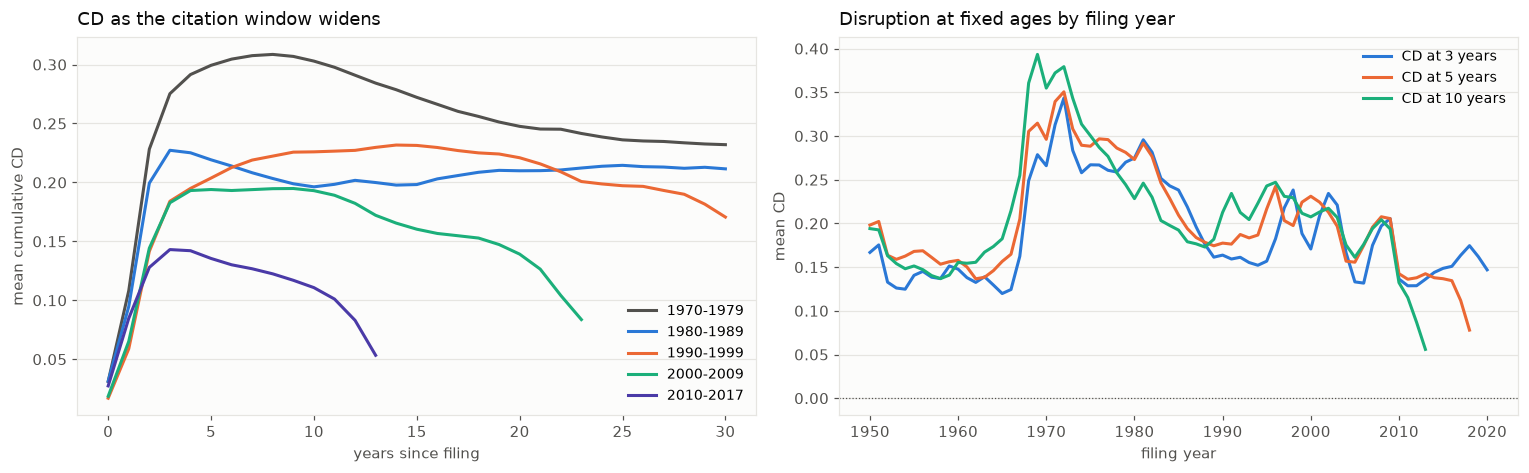

CPU times: user 1.3 s, sys: 180 ms, total: 1.48 s
Wall time: 1.39 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/patstat_validation_14.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/patstat_validation_14.pdf']

In [15]:
%%time
ts_ = q(f"SELECT filing_year AS fy, yrs_since_filing AS age, n_CD, CD_mean FROM read_parquet('{FL['disruption_trend_summary']}') WHERE n_CD > 0")
ts_['w'] = ts_.n_CD * ts_.CD_mean
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), layout='constrained')
for (lo, hi), c in zip(((1970, 1979), (1980, 1989), (1990, 1999), (2000, 2009), (2010, 2017)), (MUTED, BLUE, ORANGE, AQUA, VIOLET)):
    s = ts_[ts_.fy.between(lo, hi) & (ts_.age <= 30)].groupby('age')[['w', 'n_CD']].sum()
    s = s[s.n_CD >= 1000]; ax[0].plot(s.index, s.w / s.n_CD, lw=2, color=c, label=f'{lo}-{hi}')
style(ax[0], 'years since filing', 'mean cumulative CD', 'CD as the citation window widens'); ax[0].legend(frameon=False, fontsize=9)
for age, c in ((3, BLUE), (5, ORANGE), (10, AQUA)):
    s = ts_[(ts_.age == age) & ts_.fy.between(YEAR_MIN, SNAP - age) & (ts_.n_CD >= 1000)].sort_values('fy')
    ax[1].plot(s.fy, s.CD_mean, lw=2, color=c, label=f'CD at {age} years')
ax[1].axhline(0, color=MUTED, lw=.8, ls=':'); style(ax[1], 'filing year', 'mean CD', 'Disruption at fixed ages by filing year'); ax[1].legend(frameon=False, fontsize=9)
V.save('14')

## 15. Filing clock vs grant clock — the same granted applications on both

The grant-clock set keeps granted applications and dates both ends by grant year. For the applications in both
sets: (a) how many counted citation edges survive the switch, (b) whether impact ranks agree (Spearman of
`uniqueC_all` and of `uniqueC_5`), and (c) the CD<sub>5</sub> trend computed on each clock for the **same**
applications by filing year. Rank agreement must be high — the clocks change who is in the network and when a
window opens, not what a citation is.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,filing_edges,grant_edges,grant_over_filing_pct
0,385534965,235453552,61.07


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_15.jpg + .pdf  (600 dpi)


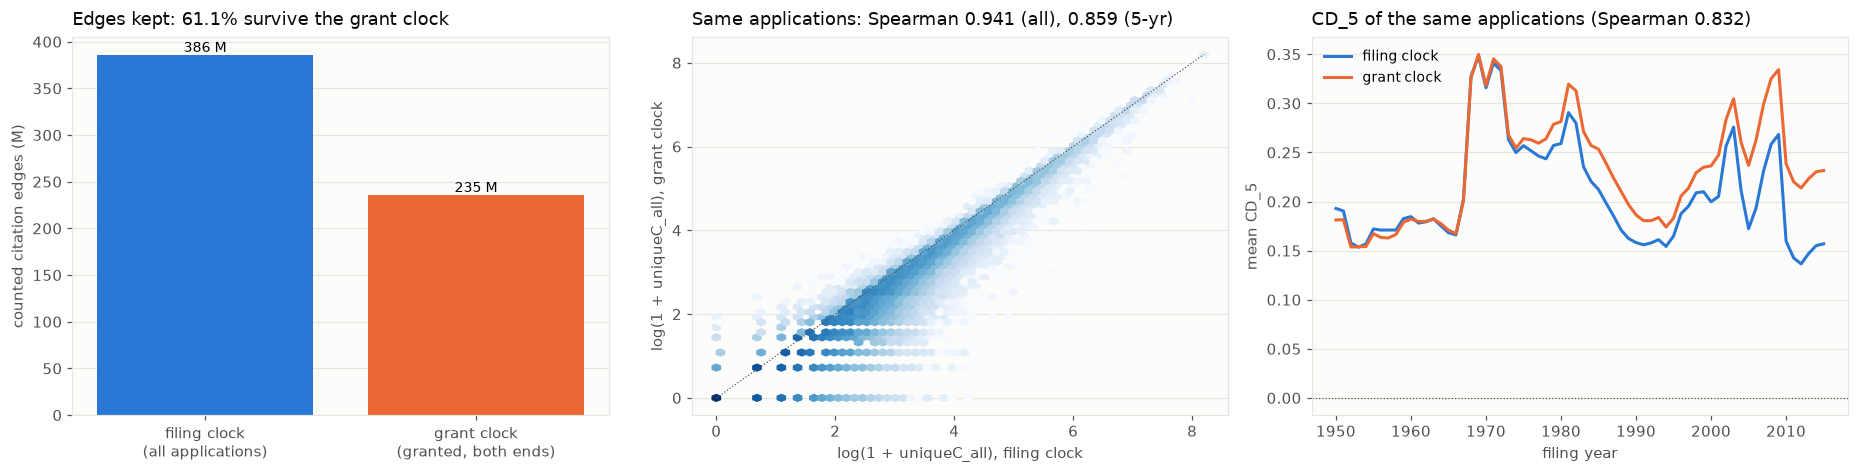

2M-sample of granted applications: Spearman uniqueC_all 0.941, uniqueC_5 0.859, CD_5 0.832 (n with CD_5 on both clocks 796,482)
CPU times: user 35.7 s, sys: 3.31 s, total: 39 s
Wall time: 30.6 s


In [16]:
%%time
e = q(f"""SELECT (SELECT count(*) FROM read_parquet('{FL['reference']}') WHERE {EDGE}) AS filing_edges,
                (SELECT count(*) FROM read_parquet('{GR['reference']}') WHERE {EDGE}) AS grant_edges""")
e['grant_over_filing_pct'] = (e.grant_edges / e.filing_edges * 100).round(2); display(e)
# deterministic ~1/20 sample of the granted applications (appln_id % 20 = 0), ~2.2 M
both = q(f"""WITH g AS (SELECT m.appln_id, m.filing_year FROM read_parquet('{GR['metadata']}') m WHERE m.appln_id % 20 = 0)
  SELECT g.filing_year, coalesce(cf.uniqueC_all, 0) AS uf_all, coalesce(cg.uniqueC_all, 0) AS ug_all,
         coalesce(cf.uniqueC_5, 0) AS uf5, coalesce(cg.uniqueC_5, 0) AS ug5, df.CD_5 AS cdf5, dg.CD_5 AS cdg5
  FROM g LEFT JOIN read_parquet('{FL['citation']}') cf USING (appln_id) LEFT JOIN read_parquet('{GR['citation']}') cg USING (appln_id)
  LEFT JOIN read_parquet('{FL['disruption']}') df USING (appln_id) LEFT JOIN read_parquet('{GR['disruption']}') dg USING (appln_id)""")
rho_all = both[['uf_all', 'ug_all']].corr(method='spearman').iloc[0, 1]
rho_5 = both[['uf5', 'ug5']].corr(method='spearman').iloc[0, 1]
cdb = both.dropna(subset=['cdf5', 'cdg5'])
rho_cd = cdb[['cdf5', 'cdg5']].corr(method='spearman').iloc[0, 1]
tr = q(f"""SELECT m.filing_year AS year, avg(df.CD_5) FILTER (WHERE dg.CD_5 IS NOT NULL) AS cdf, avg(dg.CD_5) FILTER (WHERE df.CD_5 IS NOT NULL) AS cdg,
             count(*) FILTER (WHERE df.CD_5 IS NOT NULL AND dg.CD_5 IS NOT NULL) AS n
           FROM read_parquet('{GR['metadata']}') m JOIN read_parquet('{FL['disruption']}') df USING (appln_id) JOIN read_parquet('{GR['disruption']}') dg USING (appln_id)
           WHERE m.filing_year BETWEEN {YEAR_MIN} AND {SNAP - 8} GROUP BY 1 HAVING count(*) FILTER (WHERE df.CD_5 IS NOT NULL AND dg.CD_5 IS NOT NULL) >= 1000 ORDER BY 1""")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), layout='constrained')
cnt = [e.filing_edges[0] / 1e6, e.grant_edges[0] / 1e6]
ax[0].bar(['filing clock\n(all applications)', 'grant clock\n(granted, both ends)'], cnt, color=[BLUE, ORANGE])
for i, v in enumerate(cnt):
    ax[0].text(i, v, f'{v:,.0f} M', ha='center', va='bottom', fontsize=9)
style(ax[0], None, 'counted citation edges (M)', f'Edges kept: {e.grant_over_filing_pct[0]:.1f}% survive the grant clock')
hb = ax[1].hexbin(np.log1p(both.uf_all), np.log1p(both.ug_all), gridsize=60, bins='log', cmap='Blues', mincnt=1)
lim = np.log1p(max(both.uf_all.max(), both.ug_all.max())); ax[1].plot([0, lim], [0, lim], color=MUTED, lw=.8, ls=':')
style(ax[1], 'log(1 + uniqueC_all), filing clock', 'log(1 + uniqueC_all), grant clock', f'Same applications: Spearman {rho_all:.3f} (all), {rho_5:.3f} (5-yr)')
ax[2].plot(tr.year, tr.cdf, lw=2, color=BLUE, label='filing clock'); ax[2].plot(tr.year, tr.cdg, lw=2, color=ORANGE, label='grant clock')
ax[2].axhline(0, color=MUTED, lw=.8, ls=':'); style(ax[2], 'filing year', 'mean CD_5', f'CD_5 of the same applications (Spearman {rho_cd:.3f})'); ax[2].legend(frameon=False, fontsize=9)
V.save('15')
print(f'2M-sample of granted applications: Spearman uniqueC_all {rho_all:.3f}, uniqueC_5 {rho_5:.3f}, CD_5 {rho_cd:.3f} (n with CD_5 on both clocks {len(cdb):,})')
assert rho_all > 0.8, 'impact ranks should agree across the clocks'

## 16. PATSTAT against PatentView — US grants matched by patent number

A US application's first grant publication in PATSTAT (`tls211`, kinds A / B1 / B2) carries the patent number that is
PatentView's `patent_id`. On the matched patents:

- **coverage** — the share of PatentView's utility patents found among PATSTAT's grant-clock applications, by grant year;
- **grant year** — must agree almost always (both come from the grant publication);
- **citations** — PatentView's `C_5` counts the references printed on US grants (5 years from grant), its `uniqueC_5`
  adds pre-grant application citations. The PATSTAT grant-clock edge list restricted to citing applications filed at
  the USPTO is the closest independent build, but it pools the citations of **every publication** of a citing
  application (the A1 pre-grant publication as well as the grant), so its definitional match is PatentView's
  `uniqueC_5` (the panel), not `C_5` (also in the table); it keeps granted citers only. The all-office PATSTAT
  `uniqueC_5` adds foreign citers. These are agreements in rank, reported rather than asserted;
- **CD<sub>5</sub>** — the two networks differ (US-only vs worldwide), so agreement is in rank, not level;
- **inventors** — PATSTAT `n_inventors` against PatentView's disambiguated count (asserted ≥ 99 % equal, with grant year).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,appln,patents
0,10878009,10878009,10878009


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,matched,pct_grant_year_equal,pct_filing_year_equal
0,7721435,100.0,98.989


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value
"matched patents (grant 1980-2018, 1/4 sample)",1.484397e+06
Spearman PATSTAT US-citing uniqueC_5 vs PatentView C_5,7.826000e-01
% exactly equal (US-citing vs C_5),6.033920e+01
mean PATSTAT US-citing / mean PatentView C_5,1.533200e+00
Spearman PATSTAT US-citing uniqueC_5 vs PatentView uniqueC_5,9.858000e-01
Spearman PATSTAT all-office uniqueC_5 vs PatentView uniqueC_5,9.739000e-01
mean PATSTAT all-office / mean PatentView uniqueC_5,9.297000e-01
Spearman CD_5 (both defined),7.733000e-01
n with CD_5 on both,1.211233e+06
% grant year equal (all matched),1.000000e+02


/project/jevans/Dawoon/Science of Science/validation/val_common.py:128: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] patstat_validation_16.jpg + .pdf  (600 dpi)


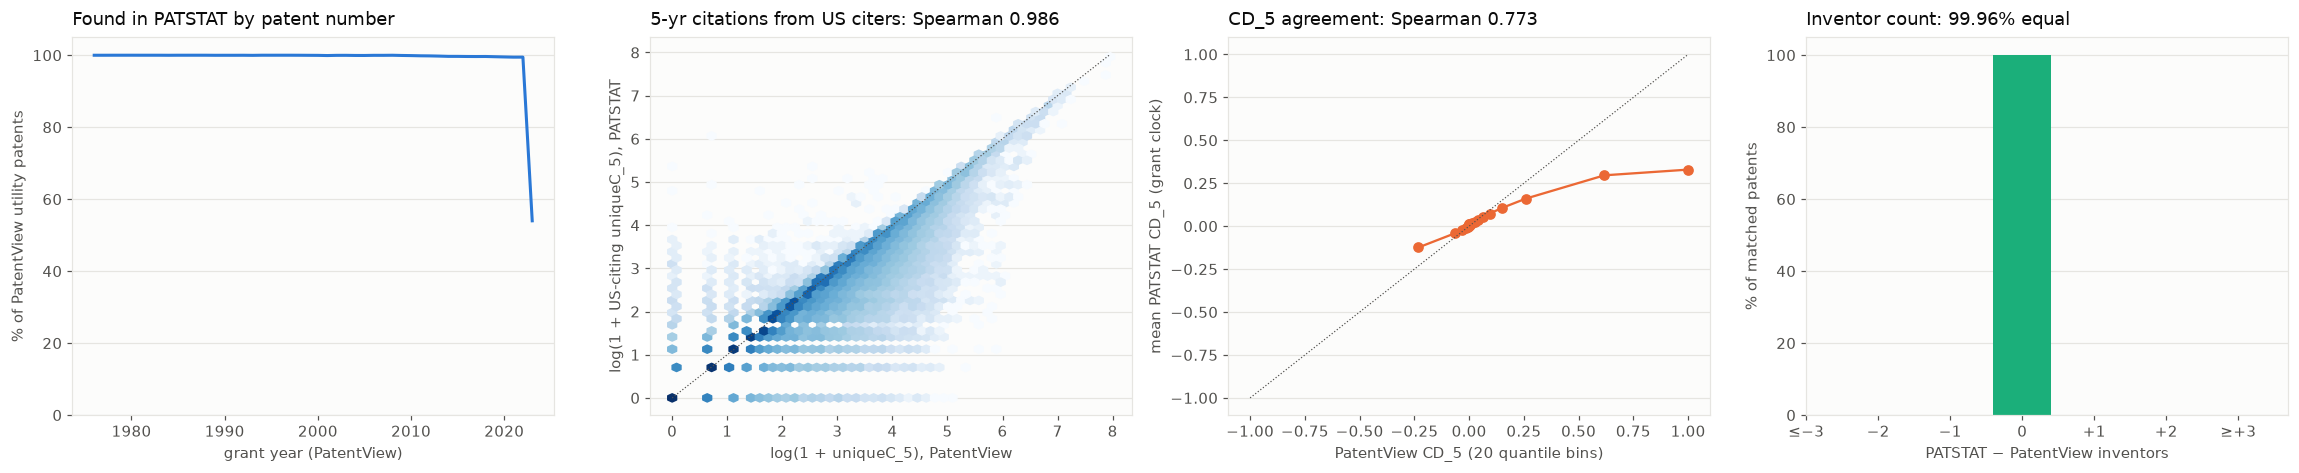

CPU times: user 1min 12s, sys: 5.75 s, total: 1min 18s
Wall time: 30.6 s


In [17]:
%%time
con.execute(f"""CREATE OR REPLACE TEMP TABLE us AS
  SELECT p.appln_id, trim(p.publn_nr) AS patent_id, year(p.publn_date) AS ps_pub_year
  FROM {ps.raw('tls211')} p WHERE p.publn_auth = 'US' AND p.publn_first_grant = 'Y' AND trim(p.publn_kind) IN ('A', 'B1', 'B2')
    AND p.appln_id IN (SELECT appln_id FROM read_parquet('{GR['metadata']}'))""")
dup = q("SELECT count(*) AS rows, count(DISTINCT appln_id) AS appln, count(DISTINCT patent_id) AS patents FROM us"); display(dup)
con.execute(f"""CREATE OR REPLACE TEMP TABLE mt AS
  SELECT u.appln_id, u.patent_id, gm.grant_year AS ps_grant_year, gm.filing_year AS ps_filing_year,
         pm.grant_year AS pv_grant_year, pm.filing_year AS pv_filing_year
  FROM us u JOIN read_parquet('{GR['metadata']}') gm USING (appln_id) JOIN read_parquet('{PV['metadata']}') pm USING (patent_id)""")
cov_y = q(f"""SELECT pm.grant_year AS year, count(*) AS pv, count(mt.patent_id) AS matched
             FROM read_parquet('{PV['metadata']}') pm LEFT JOIN mt USING (patent_id) WHERE pm.grant_year BETWEEN 1976 AND {SNAP} GROUP BY 1 ORDER BY 1""")
agree = q("""SELECT count(*) AS matched, round(100.0 * avg((ps_grant_year = pv_grant_year)::INT), 3) AS pct_grant_year_equal,
             round(100.0 * avg((ps_filing_year = pv_filing_year)::INT), 3) AS pct_filing_year_equal FROM mt""")
display(agree)
# US-citing PATSTAT count, 5 years from grant, from the grant-clock edge list
con.execute(f"""CREATE OR REPLACE TEMP TABLE ps_us5 AS
  SELECT r.cited_id AS appln_id, count(DISTINCT r.citing_id) AS ps_us_uniqueC_5
  FROM read_parquet('{GR['reference']}') r SEMI JOIN (SELECT appln_id FROM read_parquet('{GR['metadata']}') WHERE appln_auth = 'US') c ON r.citing_id = c.appln_id
  WHERE {EDGE} AND r.age <= 5 AND r.cited_id IN (SELECT appln_id FROM mt) GROUP BY 1""")
cmp = q(f"""SELECT mt.patent_id, mt.pv_grant_year AS year, coalesce(u.ps_us_uniqueC_5, 0) AS ps_us5, coalesce(gc.uniqueC_5, 0) AS ps_all5,
               coalesce(pc.C_5, 0) AS pv_C5, coalesce(pc.uniqueC_5, 0) AS pv_u5, gd.CD_5 AS ps_cd5, pd.CD_5 AS pv_cd5,
               gi.n_inventors AS ps_inv, pi.n_inventors AS pv_inv, gic.countries AS ps_ctry, pic.countries AS pv_ctry
        FROM mt LEFT JOIN ps_us5 u USING (appln_id) LEFT JOIN read_parquet('{GR['citation']}') gc USING (appln_id)
        LEFT JOIN read_parquet('{PV['citation']}') pc USING (patent_id) LEFT JOIN read_parquet('{GR['disruption']}') gd USING (appln_id)
        LEFT JOIN read_parquet('{PV['disruption']}') pd USING (patent_id) LEFT JOIN read_parquet('{GR['inventor']}') gi USING (appln_id)
        LEFT JOIN read_parquet('{PV['inventor']}') pi USING (patent_id) LEFT JOIN read_parquet('{GR['inventor_country']}') gic USING (appln_id)
        LEFT JOIN read_parquet('{PV['inventor_country']}') pic USING (patent_id)
        WHERE mt.pv_grant_year BETWEEN 1980 AND {SNAP - 5} AND mt.appln_id % 4 = 0""")      # deterministic ~1/4 sample, ~1.9 M
sp = lambda a, b, dd=cmp: dd[[a, b]].dropna().corr(method='spearman').iloc[0, 1]
cdb = cmp.dropna(subset=['ps_cd5', 'pv_cd5'])
inv = cmp.dropna(subset=['ps_inv', 'pv_inv'])
ctry = cmp.dropna(subset=['ps_ctry', 'pv_ctry'])
res = pd.Series({'matched patents (grant 1980-2018, 1/4 sample)': len(cmp),
                 'Spearman PATSTAT US-citing uniqueC_5 vs PatentView C_5': sp('ps_us5', 'pv_C5'),
                 '% exactly equal (US-citing vs C_5)': (cmp.ps_us5 == cmp.pv_C5).mean() * 100,
                 'mean PATSTAT US-citing / mean PatentView C_5': cmp.ps_us5.mean() / max(cmp.pv_C5.mean(), 1e-9),
                 'Spearman PATSTAT US-citing uniqueC_5 vs PatentView uniqueC_5': sp('ps_us5', 'pv_u5'),
                 'Spearman PATSTAT all-office uniqueC_5 vs PatentView uniqueC_5': sp('ps_all5', 'pv_u5'),
                 'mean PATSTAT all-office / mean PatentView uniqueC_5': cmp.ps_all5.mean() / max(cmp.pv_u5.mean(), 1e-9),
                 'Spearman CD_5 (both defined)': sp('ps_cd5', 'pv_cd5', cdb), 'n with CD_5 on both': len(cdb),
                 '% grant year equal (all matched)': agree.pct_grant_year_equal[0],
                 '% n_inventors equal': (inv.ps_inv == inv.pv_inv).mean() * 100, '% inventor country set equal': (ctry.ps_ctry == ctry.pv_ctry).mean() * 100})
display(res.round(4).to_frame('value'))
fig, ax = plt.subplots(1, 4, figsize=(21, 4.4), layout='constrained')
ax[0].plot(cov_y.year, cov_y.matched / cov_y.pv * 100, lw=2, color=BLUE); ax[0].set_ylim(0, 105)
style(ax[0], 'grant year (PatentView)', '% of PatentView utility patents', 'Found in PATSTAT by patent number')
hb = ax[1].hexbin(np.log1p(cmp.pv_u5), np.log1p(cmp.ps_us5), gridsize=50, bins='log', cmap='Blues', mincnt=1)
lim = np.log1p(max(cmp.pv_u5.max(), cmp.ps_us5.max())); ax[1].plot([0, lim], [0, lim], color=MUTED, lw=.8, ls=':')
style(ax[1], 'log(1 + uniqueC_5), PatentView', 'log(1 + US-citing uniqueC_5), PATSTAT',
      f"5-yr citations from US citers: Spearman {res['Spearman PATSTAT US-citing uniqueC_5 vs PatentView uniqueC_5']:.3f}")
b = cdb.assign(bin=pd.qcut(cdb.pv_cd5.rank(method='first'), 20, labels=False)).groupby('bin').agg(pv=('pv_cd5', 'mean'), ps=('ps_cd5', 'mean'))
ax[2].plot(b.pv, b.ps, 'o-', color=ORANGE); ax[2].plot([-1, 1], [-1, 1], color=MUTED, lw=.8, ls=':')
style(ax[2], 'PatentView CD_5 (20 quantile bins)', 'mean PATSTAT CD_5 (grant clock)', f"CD_5 agreement: Spearman {res['Spearman CD_5 (both defined)']:.3f}")
dd = (inv.ps_inv - inv.pv_inv).clip(-3, 3).value_counts(normalize=True).sort_index() * 100
ax[3].bar(dd.index, dd.values, color=[AQUA if i == 0 else VIOLET for i in dd.index])
ax[3].set_xticks(range(-3, 4)); ax[3].set_xticklabels(['≤−3', '−2', '−1', '0', '+1', '+2', '≥+3'])
style(ax[3], 'PATSTAT − PatentView inventors', '% of matched patents', f"Inventor count: {res['% n_inventors equal']:.2f}% equal")
V.save('16')
# identities only: both pipelines read the same grant publication and the same inventor list. The citation and CD
# agreements are reported, not asserted -- the two counts are defined on different networks (see the markdown above).
assert agree.pct_grant_year_equal[0] > 99, 'grant years of matched patents should agree'
assert res['% n_inventors equal'] > 99, 'inventor counts of matched patents should agree'

## 17. Applications vs DOCDB families — the unit, and EPO's own family count

The family set is built from the application set, so its size is fixed by identities, asserted here: one row per
DOCDB family that has a universe member; the members (`n_appln`) add up to the 84.9 M applications; no family cites
itself; nested windows and uniqueC ≤ C hold. The panels show (a) applications per filing year against families per
priority year; (b) how big the families are — the share of families and of applications by number of members in the
universe, priorities 2000–2015; (c) the family-level count of distinct citing families against PATSTAT's own
`nb_citing_docdb_fam`, which EPO computes on DOCDB families (at application level this agreement is only ρ ≈ 0.52,
§10, because one invention's citations are split over its members); (d) mean five-year citations by DOCDB family size.
Larger families are known to be more valuable inventions (Harhoff, Scherer & Vopel 2003), so impact should rise with
family size on the family unit; on the application unit each member gets a share of the family's citations instead.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,families,distinct_family_ids,families_of_the_applications,members,self_edges,window_violations
0,52766567,52766567,52766567,84914026.0,0,0


84,914,026 applications -> 52,766,567 DOCDB families (1.61 applications per family)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patstat_validation_17.jpg + .pdf  (600 dpi)


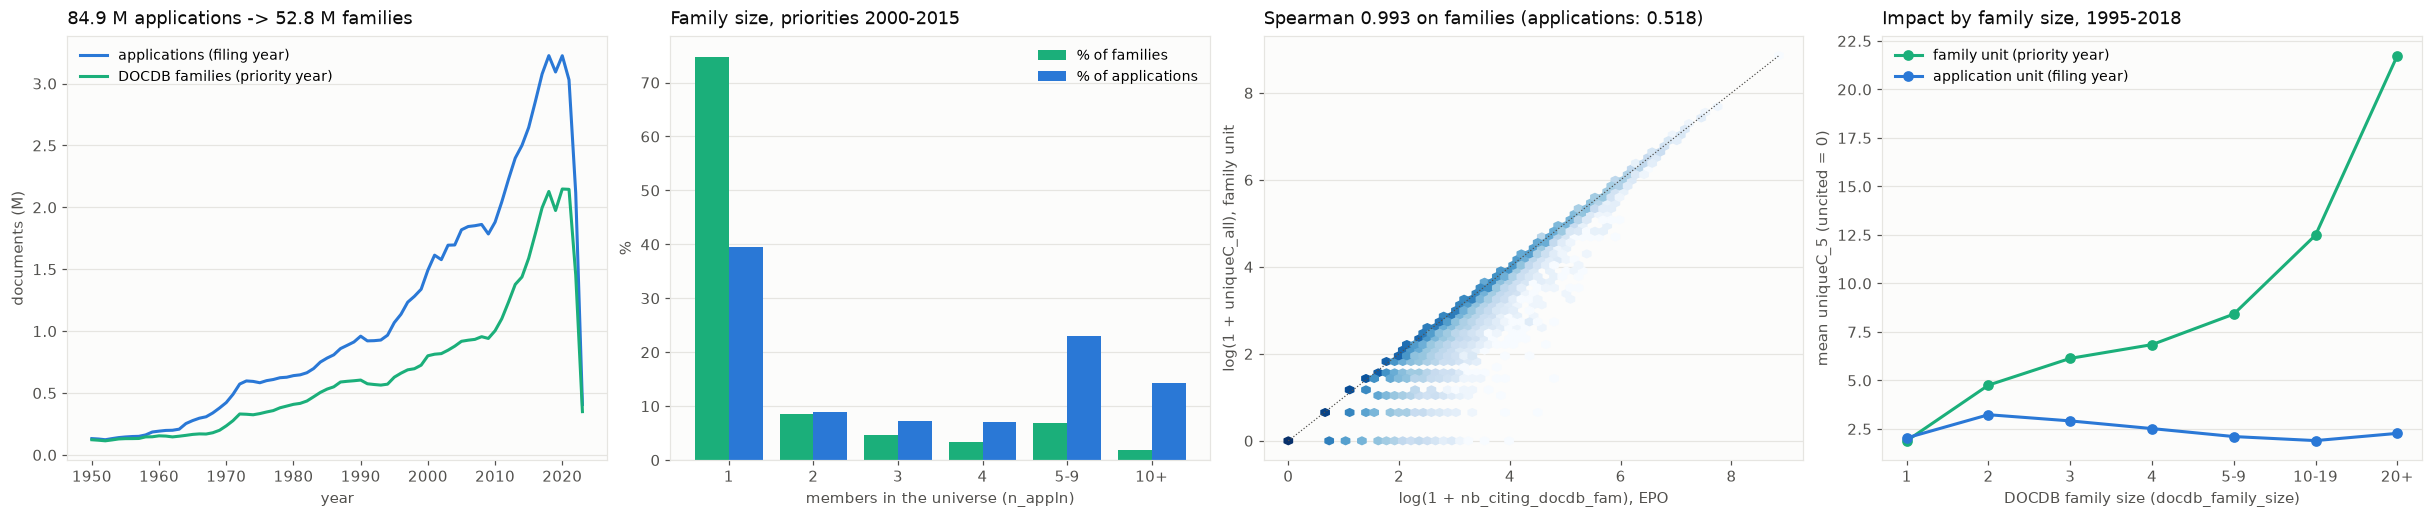

,families,applications,% families,% applications
size,,,,
1,12401126,12401126.0,74.8,39.4
2,1403630,2807260.0,8.5,8.9
3,768036,2304108.0,4.6,7.3
4,552745,2210980.0,3.3,7.0
5-9,1151786,7242865.0,6.9,23.0
10+,297491,4479391.0,1.8,14.2


,fam_u5,app_u5,n
size,,,
1,1.886,2.038,19809704
2,4.758,3.232,2042274
3,6.136,2.913,1132221
4,6.845,2.517,821569
5-9,8.418,2.106,1656791
10-19,12.489,1.897,363070
20+,21.740,2.271,61307


Spearman uniqueC_all vs nb_citing_docdb_fam: family unit 0.993 (n=2,638,425), application unit 0.518 (n=4,246,637)
CPU times: user 56.9 s, sys: 3.91 s, total: 1min
Wall time: 29.5 s


In [18]:
%%time
ident = q(f"""SELECT (SELECT count(*) FROM read_parquet('{FA['metadata']}')) AS families,
    (SELECT count(DISTINCT docdb_family_id) FROM read_parquet('{FA['metadata']}')) AS distinct_family_ids,
    (SELECT count(DISTINCT docdb_family_id) FROM read_parquet('{FL['metadata']}')) AS families_of_the_applications,
    (SELECT sum(n_appln) FROM read_parquet('{FA['metadata']}')) AS members,
    (SELECT count(*) FROM read_parquet('{FA['reference']}') WHERE citing_id = cited_id) AS self_edges,
    (SELECT count(*) FROM read_parquet('{FA['citation']}') WHERE uniqueC_all > C_all OR uniqueC_3 > uniqueC_5
        OR uniqueC_5 > uniqueC_10 OR uniqueC_10 > uniqueC_all) AS window_violations""")
display(ident)
r = ident.iloc[0]
r = {k: int(v) for k, v in r.items()}
assert r['families'] == r['distinct_family_ids'] == r['families_of_the_applications'], 'one row per DOCDB family of the universe'
assert r['members'] == N_F, f"family members ({r['members']:,}) must add up to the applications ({N_F:,})"
assert r['self_edges'] == 0 and r['window_violations'] == 0
N_FAM = r['families']
print(f'{N_F:,} applications -> {N_FAM:,} DOCDB families ({N_F / N_FAM:.2f} applications per family)')
yr = q(f"""SELECT a.year, a.applications, f.families FROM
    (SELECT filing_year AS year, count(*) AS applications FROM read_parquet('{FL['metadata']}') GROUP BY 1) a
    JOIN (SELECT priority_year AS year, count(*) AS families FROM read_parquet('{FA['metadata']}') GROUP BY 1) f USING (year)
    WHERE year BETWEEN {YEAR_MIN} AND {SNAP} ORDER BY 1""")
BUCKET = "CASE WHEN {c} >= 10 THEN '10+' WHEN {c} >= 5 THEN '5-9' ELSE {c}::VARCHAR END"
fs = q(f"""SELECT {BUCKET.format(c='n_appln')} AS size, count(*) AS families, sum(n_appln) AS applications
           FROM read_parquet('{FA['metadata']}') WHERE priority_year BETWEEN 2000 AND 2015 GROUP BY 1""").set_index('size')
fs = fs.reindex(['1', '2', '3', '4', '5-9', '10+']).fillna(0)
fs_pct = fs / fs.sum() * 100
# deterministic samples: every 20th family / application (docdb_family_id % 20 = 0 keeps whole families)
fam = q(f"""SELECT coalesce(c.uniqueC_all, 0) AS u_all, m.nb_citing_docdb_fam AS epo
            FROM read_parquet('{FA['metadata']}') m LEFT JOIN read_parquet('{FA['citation']}') c USING (docdb_family_id)
            WHERE m.docdb_family_id % 20 = 0 AND m.nb_citing_docdb_fam IS NOT NULL""")
app = q(f"""SELECT coalesce(c.uniqueC_all, 0) AS u_all, m.nb_citing_docdb_fam AS epo
            FROM read_parquet('{FL['metadata']}') m LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
            WHERE m.docdb_family_id % 20 = 0 AND m.nb_citing_docdb_fam IS NOT NULL""")
rho_fam = fam[['u_all', 'epo']].corr(method='spearman').iloc[0, 1]
rho_app = app[['u_all', 'epo']].corr(method='spearman').iloc[0, 1]
SIZE = "CASE WHEN docdb_family_size >= 20 THEN '20+' WHEN docdb_family_size >= 10 THEN '10-19' WHEN docdb_family_size >= 5 THEN '5-9' ELSE docdb_family_size::VARCHAR END"
by_size = q(f"""SELECT f.size, f.fam_u5, a.app_u5, f.n FROM
    (SELECT {SIZE} AS size, avg(coalesce(c.uniqueC_5, 0)) AS fam_u5, count(*) AS n
     FROM read_parquet('{FA['metadata']}') m LEFT JOIN read_parquet('{FA['citation']}') c USING (docdb_family_id)
     WHERE m.priority_year BETWEEN 1995 AND {SNAP - 5} GROUP BY 1) f
    JOIN (SELECT {SIZE} AS size, avg(coalesce(c.uniqueC_5, 0)) AS app_u5
     FROM read_parquet('{FL['metadata']}') m LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id)
     WHERE m.filing_year BETWEEN 1995 AND {SNAP - 5} GROUP BY 1) a USING (size)""").set_index('size')
by_size = by_size.reindex([s for s in ['1', '2', '3', '4', '5-9', '10-19', '20+'] if s in by_size.index])
fig, ax = plt.subplots(1, 4, figsize=(22, 4.6), layout='constrained')
ax[0].plot(yr.year, yr.applications / 1e6, lw=2, color=BLUE, label='applications (filing year)')
ax[0].plot(yr.year, yr.families / 1e6, lw=2, color=AQUA, label='DOCDB families (priority year)')
style(ax[0], 'year', 'documents (M)', f'{N_F / 1e6:.1f} M applications -> {N_FAM / 1e6:.1f} M families'); ax[0].legend(frameon=False, fontsize=9)
x = np.arange(len(fs_pct))
ax[1].bar(x - 0.2, fs_pct.families, width=0.4, color=AQUA, label='% of families')
ax[1].bar(x + 0.2, fs_pct.applications, width=0.4, color=BLUE, label='% of applications')
ax[1].set_xticks(x); ax[1].set_xticklabels(fs_pct.index)
style(ax[1], 'members in the universe (n_appln)', '%', 'Family size, priorities 2000-2015'); ax[1].legend(frameon=False, fontsize=9)
ax[2].hexbin(np.log1p(fam.epo), np.log1p(fam.u_all), gridsize=60, bins='log', cmap='Blues', mincnt=1)
lim = np.log1p(max(fam.epo.max(), fam.u_all.max())); ax[2].plot([0, lim], [0, lim], color=MUTED, lw=.8, ls=':')
style(ax[2], 'log(1 + nb_citing_docdb_fam), EPO', 'log(1 + uniqueC_all), family unit',
      f'Spearman {rho_fam:.3f} on families (applications: {rho_app:.3f})')
xs = np.arange(len(by_size))
ax[3].plot(xs, by_size.fam_u5, 'o-', color=AQUA, lw=2, label='family unit (priority year)')
ax[3].plot(xs, by_size.app_u5, 'o-', color=BLUE, lw=2, label='application unit (filing year)')
ax[3].set_xticks(xs); ax[3].set_xticklabels(by_size.index)
style(ax[3], 'DOCDB family size (docdb_family_size)', 'mean uniqueC_5 (uncited = 0)', 'Impact by family size, 1995-2018'); ax[3].legend(frameon=False, fontsize=9)
V.save('17', tight=False)
display(fs.assign(**{'% families': fs_pct.families.round(1), '% applications': fs_pct.applications.round(1)}))
display(by_size.round(3))
print(f'Spearman uniqueC_all vs nb_citing_docdb_fam: family unit {rho_fam:.3f} (n={len(fam):,}), application unit {rho_app:.3f} (n={len(app):,})')

## 18. Applications vs DOCDB families — citations and disruption

(a) Mean five-year citations per document by year on the two units (uncited counted as zero); a family collects the
citations of all its members, from citing families rather than citing applications, so the two series need not be
in a fixed ratio. (b) The CD<sub>5</sub> distribution of documents with at least 10 five-year citers on each unit.
(c) Mean CD<sub>5</sub> by year on each unit. (d) The same invention on both units: the family's CD<sub>5</sub> against
the CD<sub>5</sub> of its first-filed member, in 20 quantile bins, separately for one-member families (the node is the
same application, only its neighbours are merged into families) and for multi-member families. CD is asserted to
stay in [−1, 1]; the agreements are reported.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] patstat_validation_18.jpg + .pdf  (600 dpi)


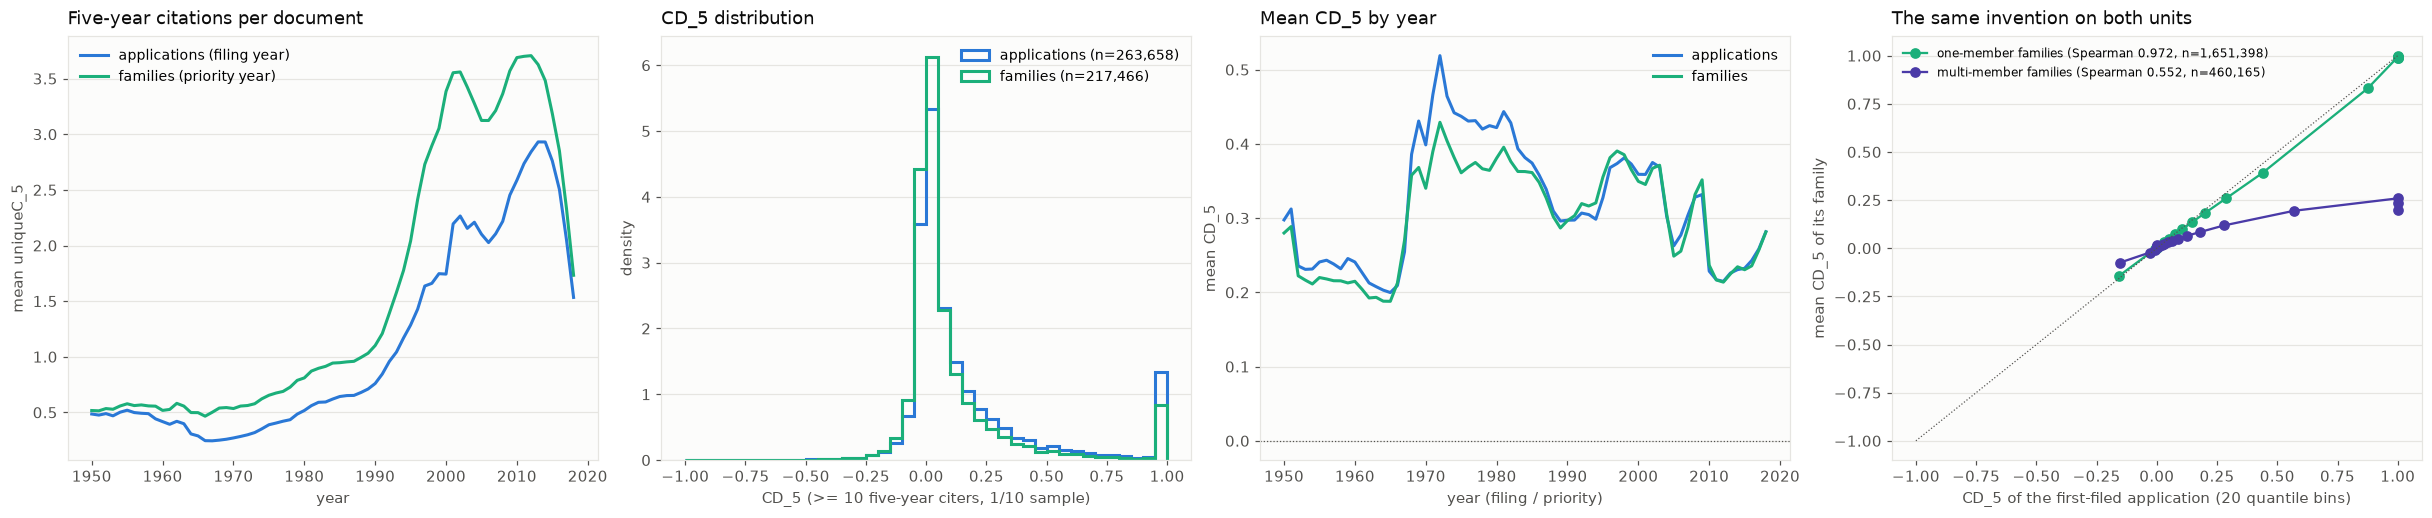

,lo,hi,n
0,-1.0,1.0,24228939


,value
"mean CD_5, applications (all years)",3.020000e-01
"mean CD_5, families (all years)",2.984000e-01
families with CD_5,2.422894e+07
"Spearman family CD_5 vs first member, one-member families",9.724000e-01
"Spearman family CD_5 vs first member, multi-member families",5.522000e-01


CPU times: user 53.1 s, sys: 3.71 s, total: 56.8 s
Wall time: 24.6 s


In [19]:
%%time
rng = q(f"SELECT min(CD_5) AS lo, max(CD_5) AS hi, count(CD_5) AS n FROM read_parquet('{FA['disruption']}')")
assert rng.lo[0] >= -1 and rng.hi[0] <= 1, 'CD_5 outside [-1, 1] on the family unit'
ci = q(f"""SELECT a.year, a.app_u5, f.fam_u5 FROM
    (SELECT m.filing_year AS year, avg(coalesce(c.uniqueC_5, 0)) AS app_u5 FROM read_parquet('{FL['metadata']}') m
       LEFT JOIN read_parquet('{FL['citation']}') c USING (appln_id) GROUP BY 1) a
    JOIN (SELECT m.priority_year AS year, avg(coalesce(c.uniqueC_5, 0)) AS fam_u5 FROM read_parquet('{FA['metadata']}') m
       LEFT JOIN read_parquet('{FA['citation']}') c USING (docdb_family_id) GROUP BY 1) f USING (year)
    WHERE year BETWEEN {YEAR_MIN} AND {SNAP - 5} ORDER BY 1""")
cdy = q(f"""SELECT a.year, a.app_cd5, f.fam_cd5 FROM
    (SELECT m.filing_year AS year, avg(d.CD_5) AS app_cd5 FROM read_parquet('{FL['metadata']}') m
       JOIN read_parquet('{FL['disruption']}') d USING (appln_id) WHERE d.CD_5 IS NOT NULL GROUP BY 1 HAVING count(*) >= 1000) a
    JOIN (SELECT m.priority_year AS year, avg(d.CD_5) AS fam_cd5 FROM read_parquet('{FA['metadata']}') m
       JOIN read_parquet('{FA['disruption']}') d USING (docdb_family_id) WHERE d.CD_5 IS NOT NULL GROUP BY 1 HAVING count(*) >= 1000) f USING (year)
    WHERE year BETWEEN {YEAR_MIN} AND {SNAP - 5} ORDER BY 1""")
BINS = np.linspace(-1, 1, 41)
def cd_hist(F, key):
    return q(f"""SELECT d.CD_5 AS cd FROM read_parquet('{F['disruption']}') d JOIN read_parquet('{F['citation']}') c USING ({key})
                 WHERE d.CD_5 IS NOT NULL AND c.uniqueC_5 >= 10 AND {key} % 10 = 0""").cd
h_app, h_fam = cd_hist(FL, 'appln_id'), cd_hist(FA, 'docdb_family_id')
same = q(f"""SELECT m.n_appln > 1 AS multi, fd.CD_5 AS fam_cd5, ad.CD_5 AS app_cd5
    FROM read_parquet('{FA['metadata']}') m JOIN read_parquet('{FA['disruption']}') fd USING (docdb_family_id)
    JOIN read_parquet('{FL['disruption']}') ad ON ad.appln_id = m.first_appln_id
    WHERE m.docdb_family_id % 10 = 0 AND fd.CD_5 IS NOT NULL AND ad.CD_5 IS NOT NULL""")
rho = {mm: g[['fam_cd5', 'app_cd5']].corr(method='spearman').iloc[0, 1] for mm, g in same.groupby('multi')}
fig, ax = plt.subplots(1, 4, figsize=(22, 4.6), layout='constrained')
ax[0].plot(ci.year, ci.app_u5, lw=2, color=BLUE, label='applications (filing year)')
ax[0].plot(ci.year, ci.fam_u5, lw=2, color=AQUA, label='families (priority year)')
style(ax[0], 'year', 'mean uniqueC_5', 'Five-year citations per document'); ax[0].legend(frameon=False, fontsize=9)
ax[1].hist(h_app, bins=BINS, density=True, histtype='step', lw=2, color=BLUE, label=f'applications (n={len(h_app):,})')
ax[1].hist(h_fam, bins=BINS, density=True, histtype='step', lw=2, color=AQUA, label=f'families (n={len(h_fam):,})')
style(ax[1], 'CD_5 (>= 10 five-year citers, 1/10 sample)', 'density', 'CD_5 distribution'); ax[1].legend(frameon=False, fontsize=9)
ax[2].plot(cdy.year, cdy.app_cd5, lw=2, color=BLUE, label='applications'); ax[2].plot(cdy.year, cdy.fam_cd5, lw=2, color=AQUA, label='families')
ax[2].axhline(0, color=MUTED, lw=.8, ls=':'); style(ax[2], 'year (filing / priority)', 'mean CD_5', 'Mean CD_5 by year'); ax[2].legend(frameon=False, fontsize=9)
for mm, col, lab in ((False, AQUA, 'one-member families'), (True, VIOLET, 'multi-member families')):
    g = same[same.multi == mm]
    if len(g) < 100:
        continue
    b = g.assign(bin=pd.qcut(g.app_cd5.rank(method='first'), 20, labels=False)).groupby('bin').agg(app=('app_cd5', 'mean'), fam=('fam_cd5', 'mean'))
    ax[3].plot(b.app, b.fam, 'o-', color=col, label=f'{lab} (Spearman {rho[mm]:.3f}, n={len(g):,})')
ax[3].plot([-1, 1], [-1, 1], color=MUTED, lw=.8, ls=':')
style(ax[3], 'CD_5 of the first-filed application (20 quantile bins)', 'mean CD_5 of its family', 'The same invention on both units')
ax[3].legend(frameon=False, fontsize=8)
V.save('18', tight=False)
display(rng)
summ = pd.Series({'mean CD_5, applications (all years)': q(f"SELECT avg(CD_5) FROM read_parquet('{FL['disruption']}')").iloc[0, 0],
                  'mean CD_5, families (all years)': q(f"SELECT avg(CD_5) FROM read_parquet('{FA['disruption']}')").iloc[0, 0],
                  'families with CD_5': rng.n[0],
                  'Spearman family CD_5 vs first member, one-member families': rho.get(False, np.nan),
                  'Spearman family CD_5 vs first member, multi-member families': rho.get(True, np.nan)})
display(summ.round(4).to_frame('value'))
con.close()